# Mini Project Notebook: Credit Card Clustering


In [5]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Optional (for warnings)
import warnings
warnings.filterwarnings('ignore')

## Dataset Exploration



Load the dataset "CreditCards.csv" into a Pandas DataFrame. Display the first 15 rows and all columns.

In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv("CreditCards (1).csv")

# Display all columns
pd.set_option('display.max_columns', None)

# Show first 15 rows
df.head(15)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


Determine the data types of each column in the DataFrame. Check for missing values and count the number of missing values in each column.

In [7]:
# Combine dtype + missing values
summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum()
})

summary

,Data Type,Missing Values
CUST_ID,str,0
BALANCE,float64,0
BALANCE_FREQUENCY,float64,0
PURCHASES,float64,0
ONEOFF_PURCHASES,float64,0
INSTALLMENTS_PURCHASES,float64,0
CASH_ADVANCE,float64,0
PURCHASES_FREQUENCY,float64,0
ONEOFF_PURCHASES_FREQUENCY,float64,0
PURCHASES_INSTALLMENTS_FREQUENCY,float64,0


Check the data types of all columns and ensure they are consistent with the expected types (e.g., numerical for quantities, categorical for identifiers).

In [8]:
import pandas as pd

# Summary + type check + basic fixing
summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum()
})

# Attempt to correct data types
for col in df.columns:
    if df[col].dtype == 'object':
        # Try numeric conversion
        df[col] = pd.to_numeric(df[col], errors='ignore')
        # Try datetime conversion
        df[col] = pd.to_datetime(df[col], errors='ignore')

# Separate columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Display results
print("=== Summary ===")
print(summary)

print("\n=== Numerical Columns ===")
print(list(num_cols))

print("\n=== Categorical Columns ===")
print(list(cat_cols))

print("\n=== Updated Data Types ===")
print(df.dtypes)

=== Summary ===
                                 Data Type  Missing Values
CUST_ID                                str               0
BALANCE                            float64               0
BALANCE_FREQUENCY                  float64               0
PURCHASES                          float64               0
ONEOFF_PURCHASES                   float64               0
INSTALLMENTS_PURCHASES             float64               0
CASH_ADVANCE                       float64               0
PURCHASES_FREQUENCY                float64               0
ONEOFF_PURCHASES_FREQUENCY         float64               0
PURCHASES_INSTALLMENTS_FREQUENCY   float64               0
CASH_ADVANCE_FREQUENCY             float64               0
CASH_ADVANCE_TRX                     int64               0
PURCHASES_TRX                        int64               0
CREDIT_LIMIT                       float64               1
PAYMENTS                           float64               0
MINIMUM_PAYMENTS                   float

Convert data types if necessary (e.g., convert object columns to numeric if appropriate).

In [9]:
import pandas as pd

for col in df.columns:
    if df[col].dtype == 'object':
        
        # Try converting to numeric
        converted_num = pd.to_numeric(df[col], errors='coerce')
        
        # If most values are numeric, keep conversion
        if converted_num.notnull().sum() > 0.7 * len(df):
            df[col] = converted_num
        else:
            # Try converting to datetime
            converted_date = pd.to_datetime(df[col], errors='coerce')
            
            if converted_date.notnull().sum() > 0.7 * len(df):
                df[col] = converted_date
            else:
                # Keep as categorical (string)
                df[col] = df[col].astype('string')

# Final data types check
print(df.dtypes)

CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


Calculate summary statistics (mean, median, mode, standard deviation, min, max, quartiles) for numerical columns.

In [10]:
import pandas as pd

# Select numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate summary statistics
summary_stats = pd.DataFrame({
    'Mean': num_df.mean(),
    'Median': num_df.median(),
    'Mode': num_df.mode().iloc[0],
    'Std Dev': num_df.std(),
    'Min': num_df.min(),
    '25% (Q1)': num_df.quantile(0.25),
    '50% (Q2)': num_df.quantile(0.50),
    '75% (Q3)': num_df.quantile(0.75),
    'Max': num_df.max()
})

summary_stats

,Mean,Median,Mode,Std Dev,Min,25% (Q1),50% (Q2),75% (Q3),Max
BALANCE,1564.474828,873.385231,0.000000,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,0.877271,1.000000,1.000000,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,1003.204834,361.280000,0.000000,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,592.437371,38.000000,0.000000,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,411.067645,89.000000,0.000000,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,978.871112,0.000000,0.000000,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,0.490351,0.500000,1.000000,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,0.202458,0.083333,0.000000,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,0.364437,0.166667,0.000000,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,0.135144,0.000000,0.000000,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


Calculate the correlation between numerical variables. Visualize the correlation matrix using a heatmap.

                                   BALANCE  BALANCE_FREQUENCY  PURCHASES  \
BALANCE                           1.000000           0.322412   0.181261   
BALANCE_FREQUENCY                 0.322412           1.000000   0.133674   
PURCHASES                         0.181261           0.133674   1.000000   
ONEOFF_PURCHASES                  0.164350           0.104323   0.916845   
INSTALLMENTS_PURCHASES            0.126469           0.124292   0.679896   
CASH_ADVANCE                      0.496692           0.099388  -0.051474   
PURCHASES_FREQUENCY              -0.077944           0.229715   0.393017   
ONEOFF_PURCHASES_FREQUENCY        0.073166           0.202415   0.498430   
PURCHASES_INSTALLMENTS_FREQUENCY -0.063186           0.176079   0.315567   
CASH_ADVANCE_FREQUENCY            0.449218           0.191873  -0.120143   
CASH_ADVANCE_TRX                  0.385152           0.141555  -0.067175   
PURCHASES_TRX                     0.154338           0.189626   0.689561   
CREDIT_LIMIT

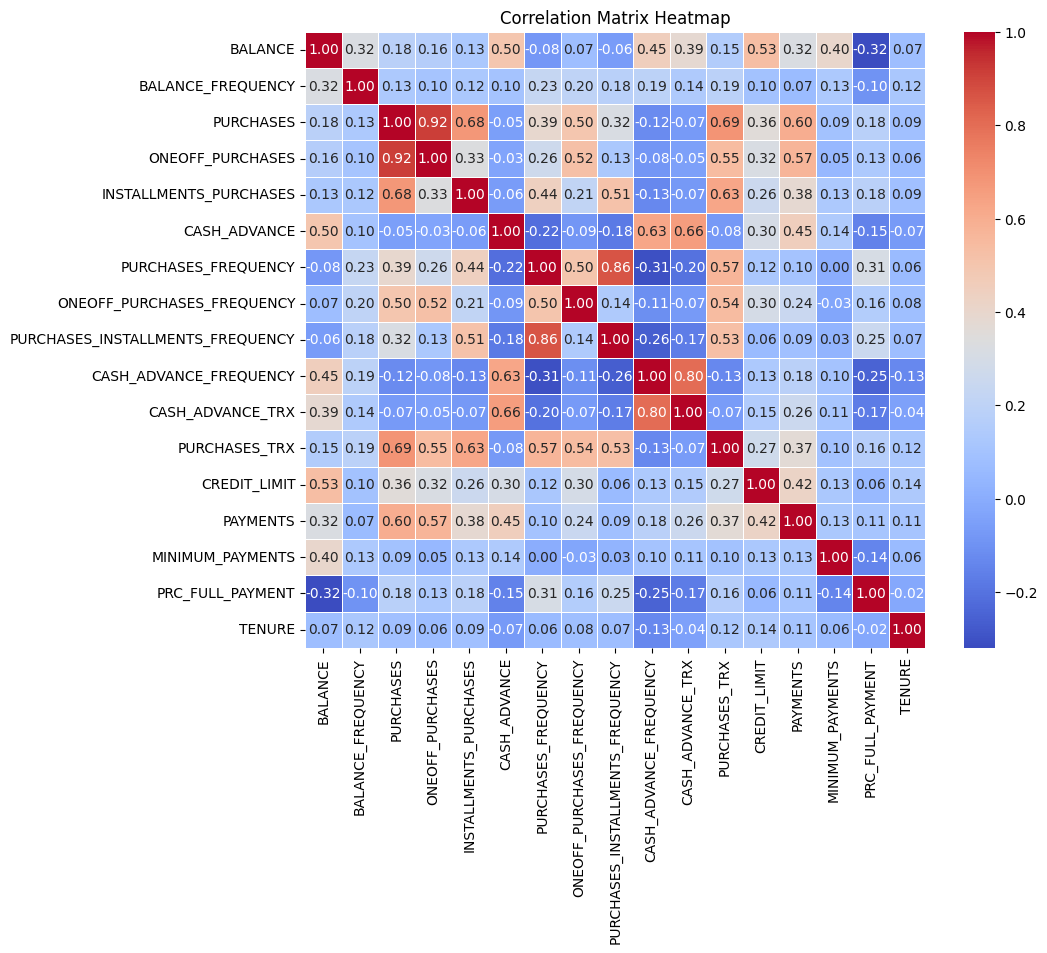

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = num_df.corr()

# Display correlation values
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

Analyze the distribution of categorical variables (e.g., count the occurrences of different values in the CUST_ID column).

In [12]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    print(f"\n=== Distribution of {col} ===")
    
    # Count occurrences
    counts = df[col].value_counts()
    print(counts)
    
    # Percentage distribution
    percentages = df[col].value_counts(normalize=True) * 100
    print("\nPercentage Distribution:")
    print(percentages)


=== Distribution of CUST_ID ===
CUST_ID
C10001    1
C10002    1
C10003    1
C10004    1
C10005    1
         ..
C19186    1
C19187    1
C19188    1
C19189    1
C19190    1
Name: count, Length: 8950, dtype: int64

Percentage Distribution:
CUST_ID
C10001    0.011173
C10002    0.011173
C10003    0.011173
C10004    0.011173
C10005    0.011173
            ...   
C19186    0.011173
C19187    0.011173
C19188    0.011173
C19189    0.011173
C19190    0.011173
Name: proportion, Length: 8950, dtype: float64


Identify outliers using box plots or statistical methods (e.g., IQR).

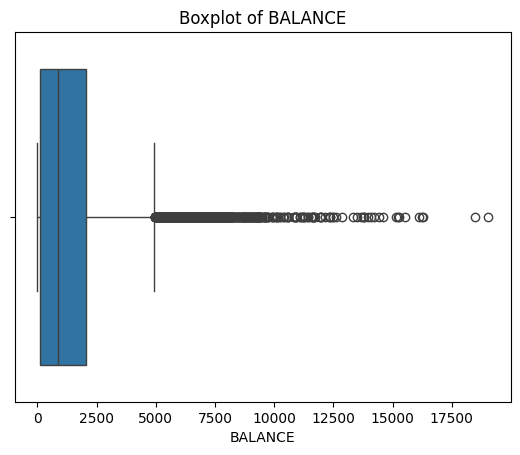

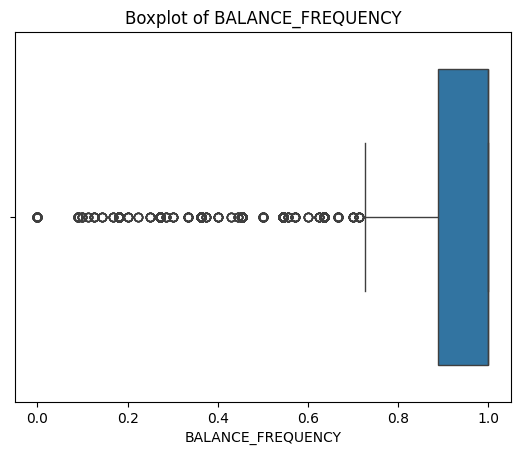

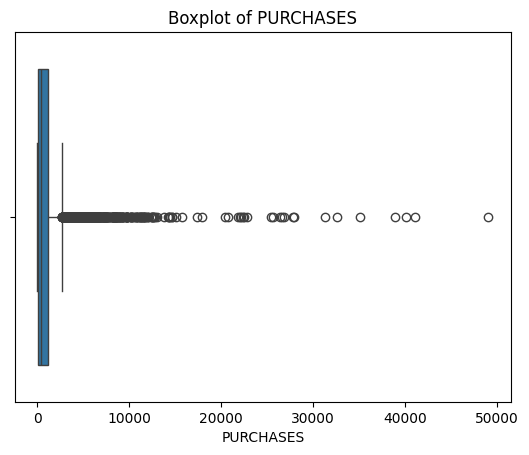

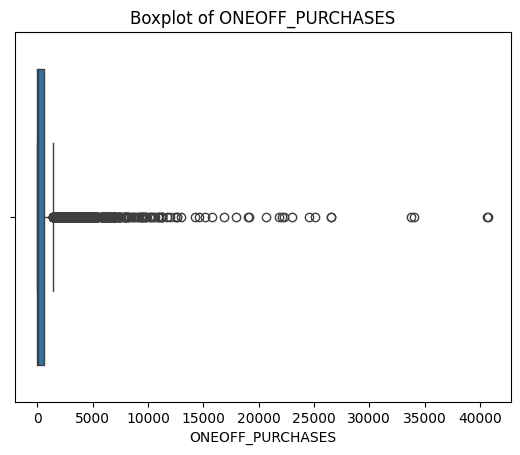

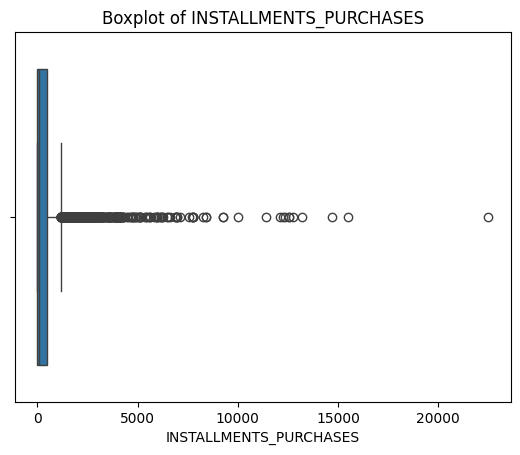

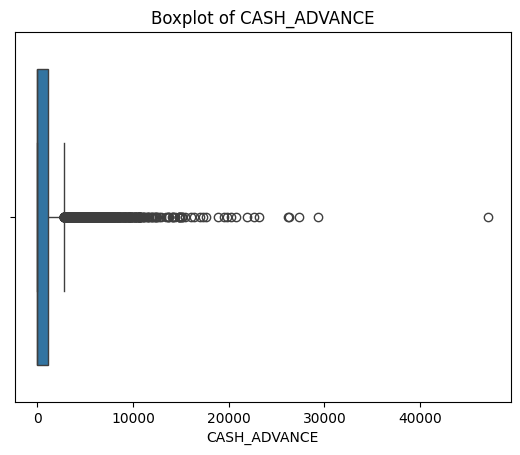

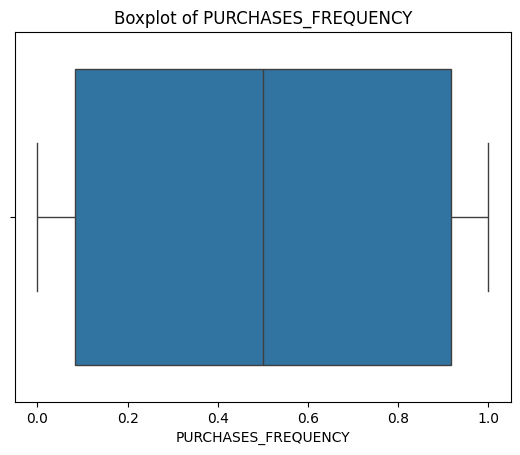

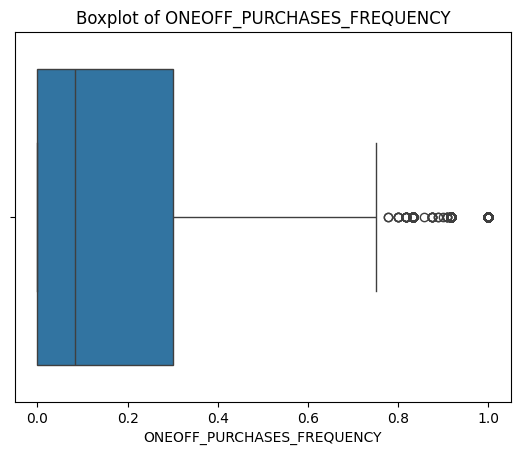

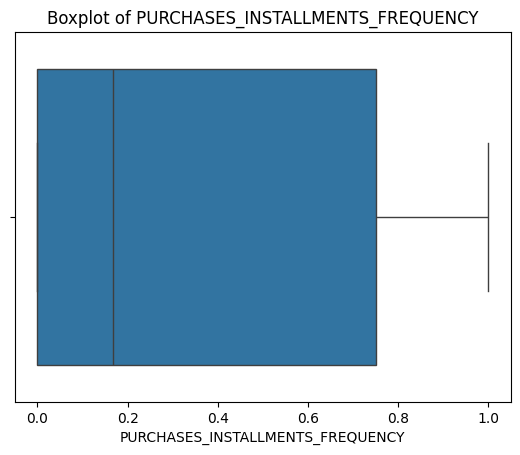

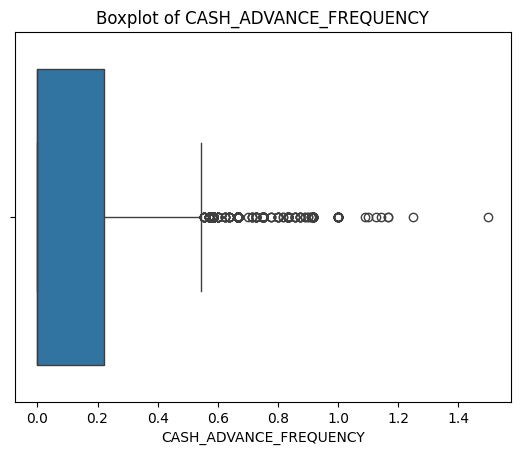

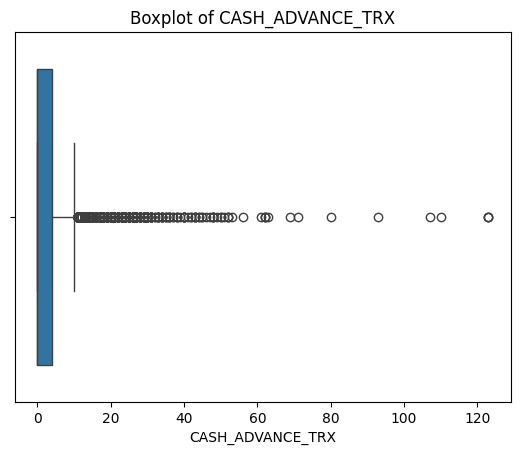

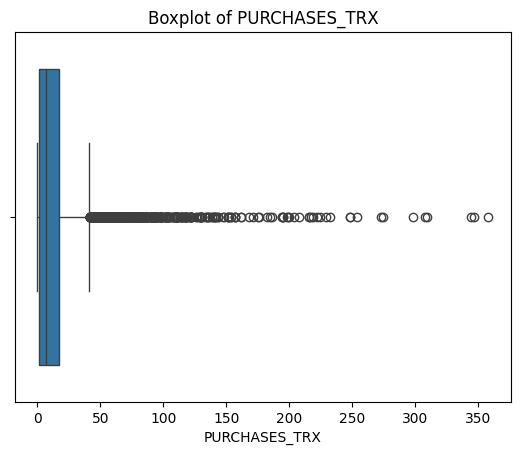

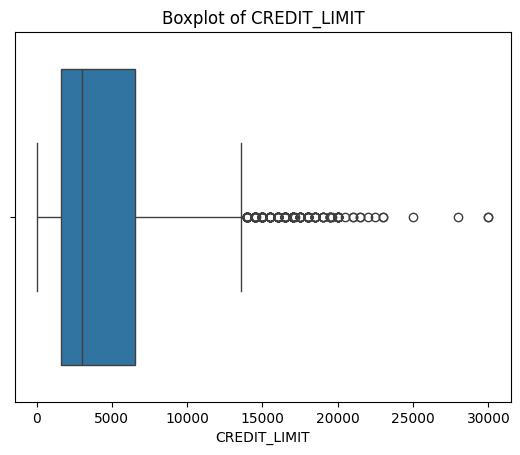

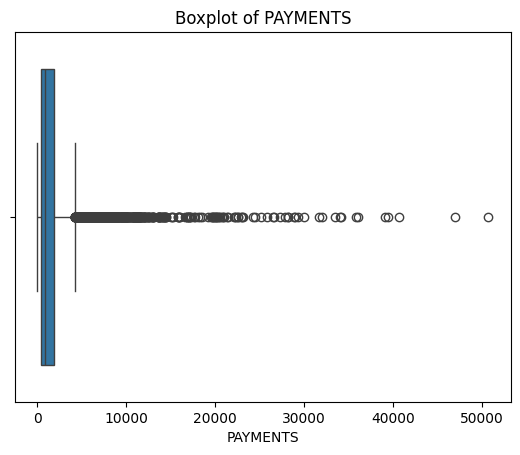

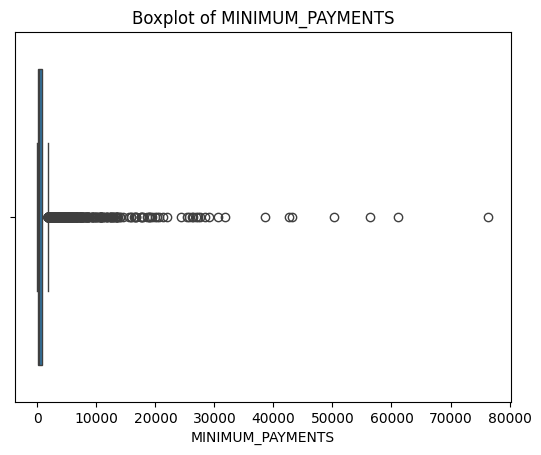

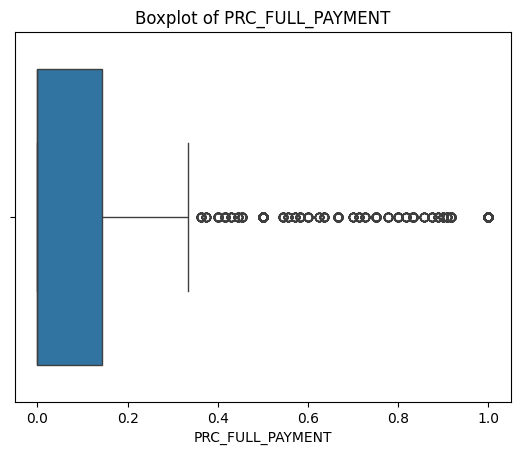

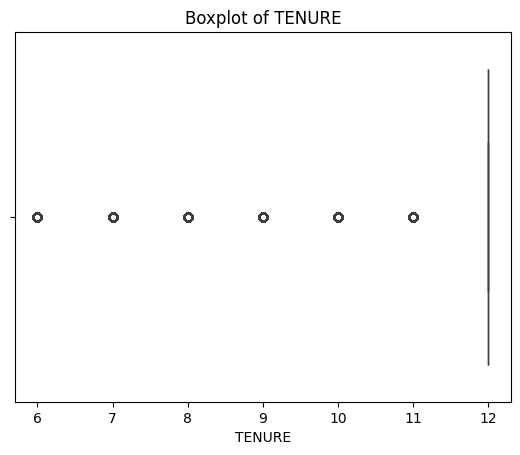

=== Outlier Count per Column ===
{'BALANCE': 695, 'BALANCE_FREQUENCY': 1493, 'PURCHASES': 808, 'ONEOFF_PURCHASES': 1013, 'INSTALLMENTS_PURCHASES': 867, 'CASH_ADVANCE': 1030, 'PURCHASES_FREQUENCY': 0, 'ONEOFF_PURCHASES_FREQUENCY': 782, 'PURCHASES_INSTALLMENTS_FREQUENCY': 0, 'CASH_ADVANCE_FREQUENCY': 525, 'CASH_ADVANCE_TRX': 804, 'PURCHASES_TRX': 766, 'CREDIT_LIMIT': 248, 'PAYMENTS': 808, 'MINIMUM_PAYMENTS': 841, 'PRC_FULL_PAYMENT': 1474, 'TENURE': 1366}


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

outliers_summary = {}

for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = num_df[(num_df[col] < lower_bound) | (num_df[col] > upper_bound)]

    outliers_summary[col] = len(outliers)

    # Boxplot
    plt.figure()
    sns.boxplot(x=num_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Print outlier counts
print("=== Outlier Count per Column ===")
print(outliers_summary)

Visualize the impact of outliers: Remove outliers and re-visualize the data to assess their impact on the overall distribution and relationships.

=== Before Removing Outliers ===


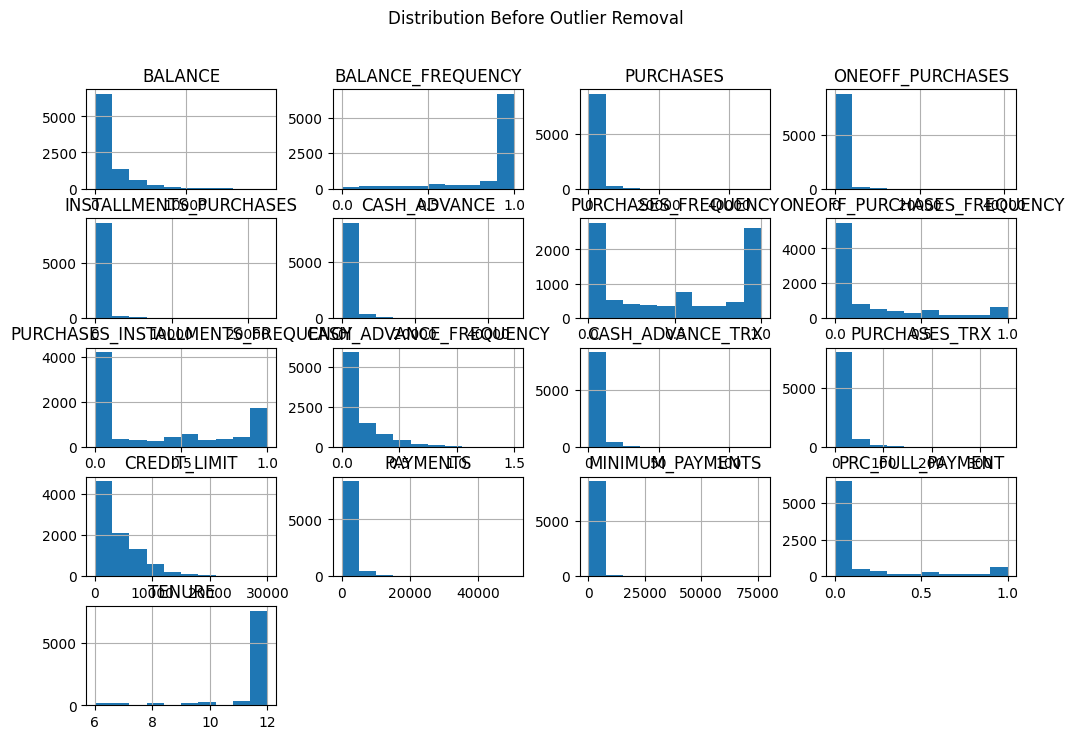

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# --- BEFORE REMOVING OUTLIERS ---
print("=== Before Removing Outliers ===")
num_df.hist(figsize=(12, 8))
plt.suptitle("Distribution Before Outlier Removal")
plt.show()

sns.pairplot(num_df)
plt.suptitle("Relationships Before Outlier Removal", y=1.02)
plt.show()

# --- REMOVE OUTLIERS USING IQR ---
df_clean = num_df.copy()

for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

# --- AFTER REMOVING OUTLIERS ---
print("=== After Removing Outliers ===")
df_clean.hist(figsize=(12, 8))
plt.suptitle("Distribution After Outlier Removal")
plt.show()

sns.pairplot(df_clean)
plt.suptitle("Relationships After Outlier Removal", y=1.02)
plt.show()

Identify missing values in the dataset and calculate the percentage of missing data for each column.

In [ ]:
import pandas as pd

# Calculate missing values and percentage
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

# Display only columns with missing values (optional)
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

missing_summary

,Missing Values,Percentage (%)
CREDIT_LIMIT,1,0.011173
MINIMUM_PAYMENTS,313,3.497207


Handle missing values (e.g., imputation, deletion) and outliers (e.g., capping, removal).

In [ ]:
import pandas as pd
import numpy as np

# Separate columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# --- HANDLE MISSING VALUES ---

# Numerical → fill with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → fill with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# --- HANDLE OUTLIERS USING CAPPING (WINSORIZATION) ---

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Final check
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


For categorical columns, impute missing values with the most frequent category or a new category.

In [ ]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    
    # Option 1: Fill with most frequent value (mode)
    if df[col].mode().empty:
        df[col].fillna("Unknown", inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

    # Option 2 (alternative): Uncomment below to use "Unknown" instead
    # df[col].fillna("Unknown", inplace=True)

# Check results
print(df[cat_cols].isnull().sum())

CUST_ID    0
dtype: int64


Explore the relationship between categorical variables and numerical variables (e.g., calculate the average BALANCE for different CUST_ID categories).


=== Average BALANCE for each CUST_ID ===
CUST_ID
C10031    4942.927215
C14990    4942.927215
C10029    4942.927215
C15012    4942.927215
C10788    4942.927215
             ...     
C16502       0.000000
C13556       0.000000
C12246       0.000000
C15076       0.000000
C17244       0.000000
Name: BALANCE, Length: 8950, dtype: float64


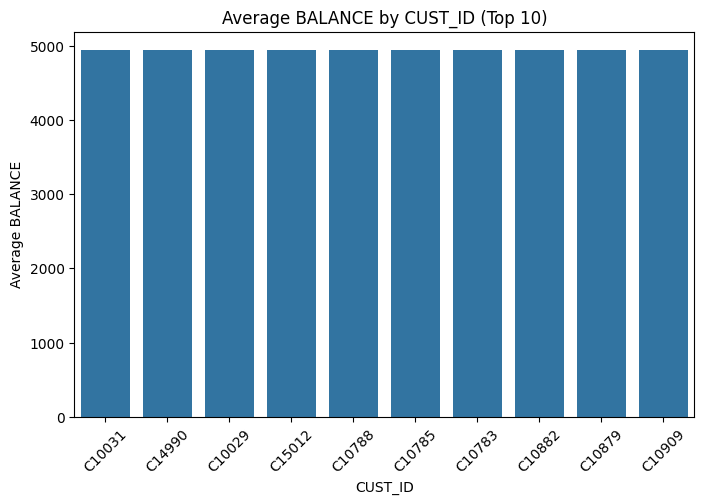


=== Average BALANCE_FREQUENCY for each CUST_ID ===
CUST_ID
C19187    1.000000
C19186    1.000000
C19169    1.000000
C19168    1.000000
C19166    1.000000
            ...   
C19155    0.722223
C10023    0.722223
C10048    0.722223
C16350    0.722223
C16366    0.722223
Name: BALANCE_FREQUENCY, Length: 8950, dtype: float64


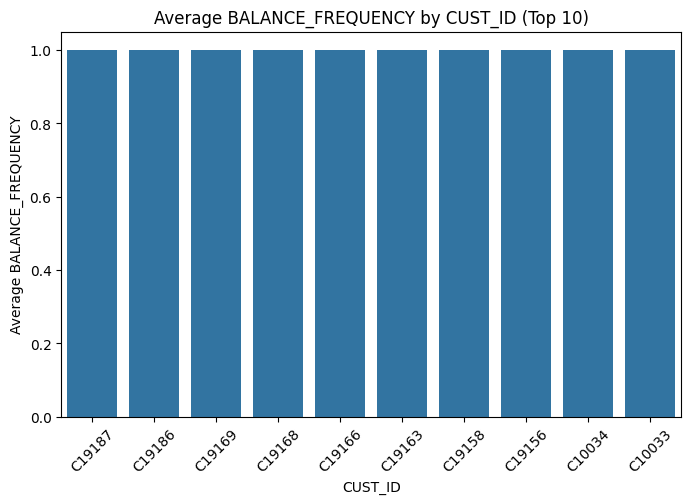


=== Average PURCHASES for each CUST_ID ===
CUST_ID
C10031    2715.8725
C10007    2715.8725
C10024    2715.8725
C15670    2715.8725
C11765    2715.8725
            ...    
C11705       0.0000
C15761       0.0000
C15760       0.0000
C15758       0.0000
C14813       0.0000
Name: PURCHASES, Length: 8950, dtype: float64


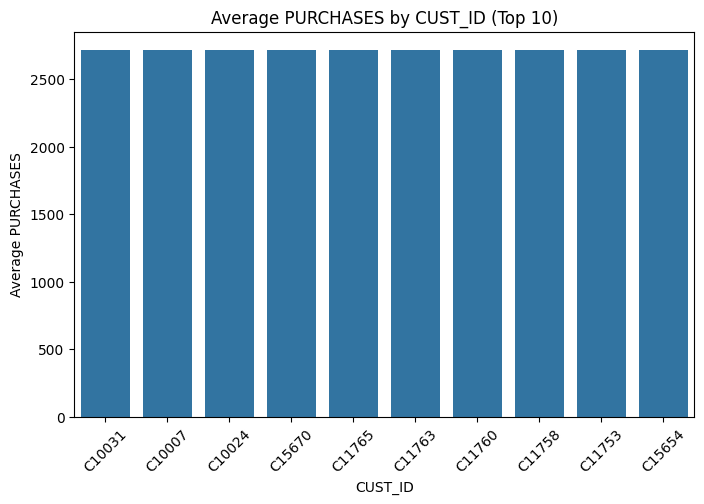


=== Average ONEOFF_PURCHASES for each CUST_ID ===
CUST_ID
C10024    1443.5125
C10022    1443.5125
C19138    1443.5125
C10004    1443.5125
C10007    1443.5125
            ...    
C19177       0.0000
C19176       0.0000
C19175       0.0000
C19173       0.0000
C10016       0.0000
Name: ONEOFF_PURCHASES, Length: 8950, dtype: float64


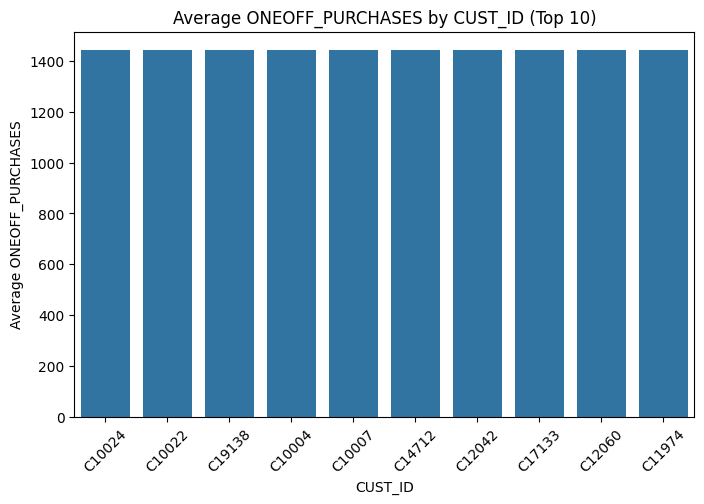


=== Average INSTALLMENTS_PURCHASES for each CUST_ID ===
CUST_ID
C15122    1171.59375
C15118    1171.59375
C11685    1171.59375
C11677    1171.59375
C11670    1171.59375
             ...    
C19140       0.00000
C19142       0.00000
C19119       0.00000
C10033       0.00000
C10005       0.00000
Name: INSTALLMENTS_PURCHASES, Length: 8950, dtype: float64


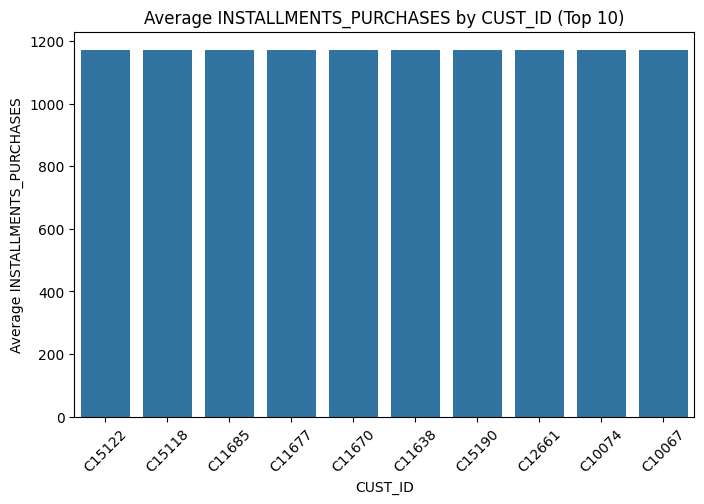


=== Average CASH_ADVANCE for each CUST_ID ===
CUST_ID
C10031    2784.552848
C10002    2784.552848
C13945    2784.552848
C13948    2784.552848
C13956    2784.552848
             ...     
C19138       0.000000
C13711       0.000000
C19141       0.000000
C19143       0.000000
C10001       0.000000
Name: CASH_ADVANCE, Length: 8950, dtype: float64


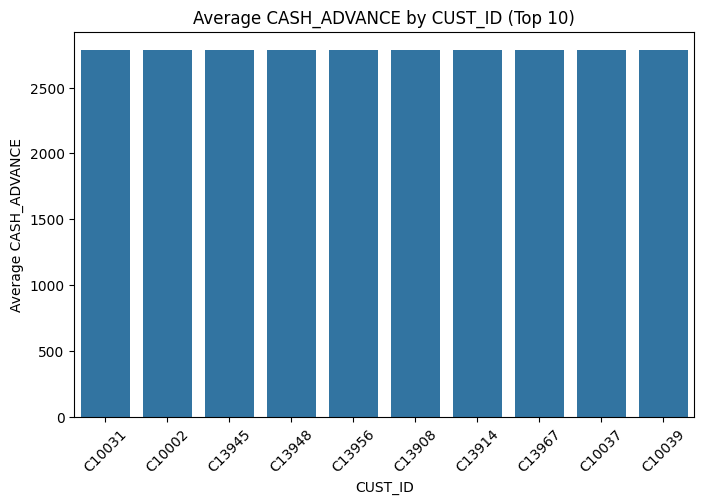


=== Average PURCHASES_FREQUENCY for each CUST_ID ===
CUST_ID
C10007    1.0
C10008    1.0
C10011    1.0
C19187    1.0
C19171    1.0
         ... 
C17080    0.0
C17073    0.0
C11952    0.0
C11948    0.0
C19158    0.0
Name: PURCHASES_FREQUENCY, Length: 8950, dtype: float64


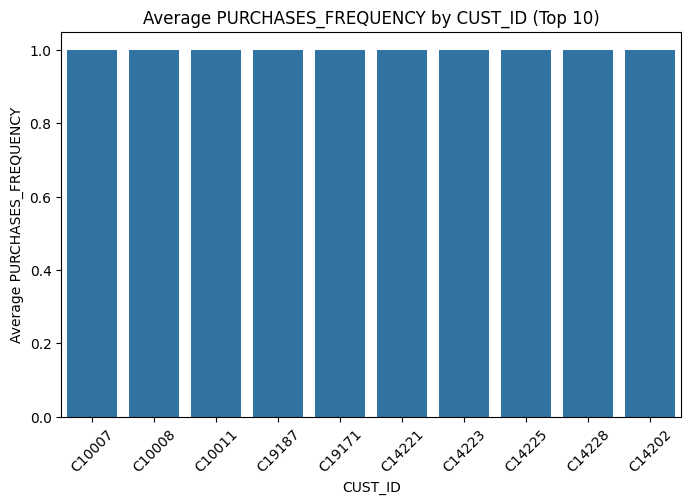


=== Average ONEOFF_PURCHASES_FREQUENCY for each CUST_ID ===
CUST_ID
C10022    0.75
C10003    0.75
C17877    0.75
C17876    0.75
C11260    0.75
          ... 
C19183    0.00
C19182    0.00
C19181    0.00
C19179    0.00
C19178    0.00
Name: ONEOFF_PURCHASES_FREQUENCY, Length: 8950, dtype: float64


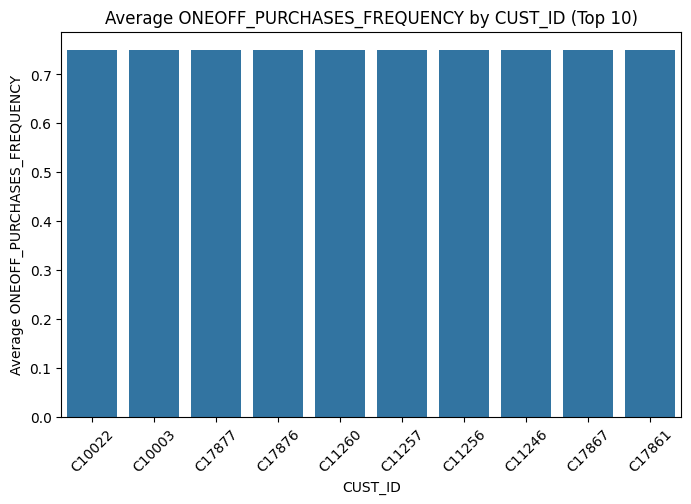


=== Average PURCHASES_INSTALLMENTS_FREQUENCY for each CUST_ID ===
CUST_ID
C10032    1.0
C10007    1.0
C10008    1.0
C10031    1.0
C10028    1.0
         ... 
C10049    0.0
C14217    0.0
C14216    0.0
C14214    0.0
C19185    0.0
Name: PURCHASES_INSTALLMENTS_FREQUENCY, Length: 8950, dtype: float64


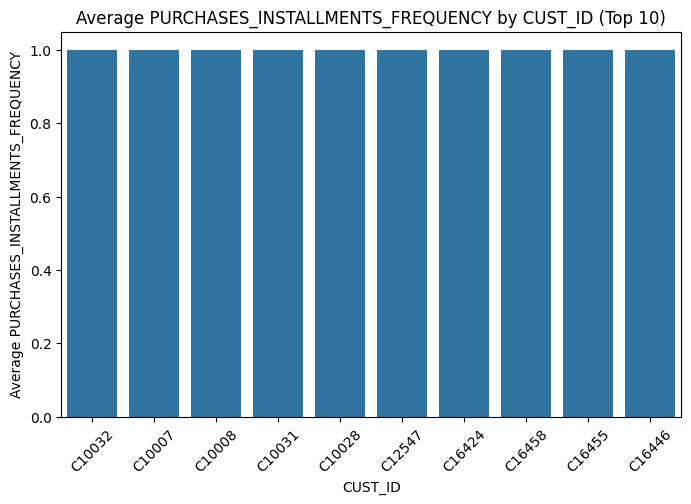


=== Average CASH_ADVANCE_FREQUENCY for each CUST_ID ===
CUST_ID
C12279    0.555555
C19156    0.555555
C15725    0.555555
C11136    0.555555
C11132    0.555555
            ...   
C10020    0.000000
C10021    0.000000
C10023    0.000000
C10026    0.000000
C10028    0.000000
Name: CASH_ADVANCE_FREQUENCY, Length: 8950, dtype: float64


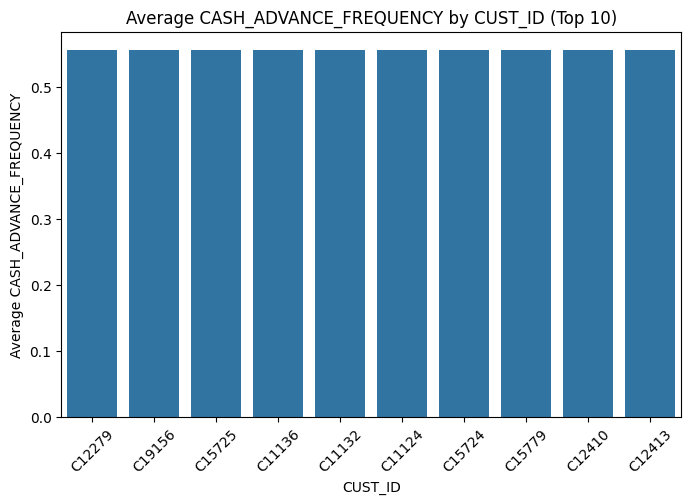


=== Average CASH_ADVANCE_TRX for each CUST_ID ===
CUST_ID
C19182    10.0
C12946    10.0
C12953    10.0
C12873    10.0
C12970    10.0
          ... 
C10013     0.0
C10012     0.0
C10011     0.0
C10010     0.0
C10001     0.0
Name: CASH_ADVANCE_TRX, Length: 8950, dtype: float64


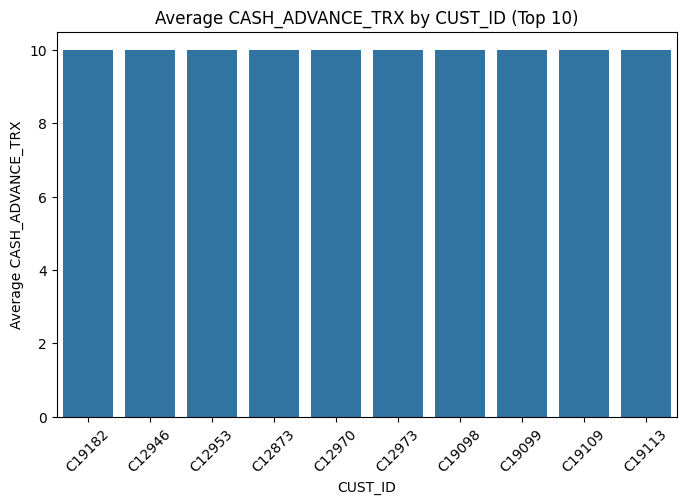


=== Average PURCHASES_TRX for each CUST_ID ===
CUST_ID
C10032    41.0
C10007    41.0
C10031    41.0
C10022    41.0
C13495    41.0
          ... 
C16393     0.0
C11705     0.0
C11713     0.0
C12928     0.0
C19119     0.0
Name: PURCHASES_TRX, Length: 8950, dtype: float64


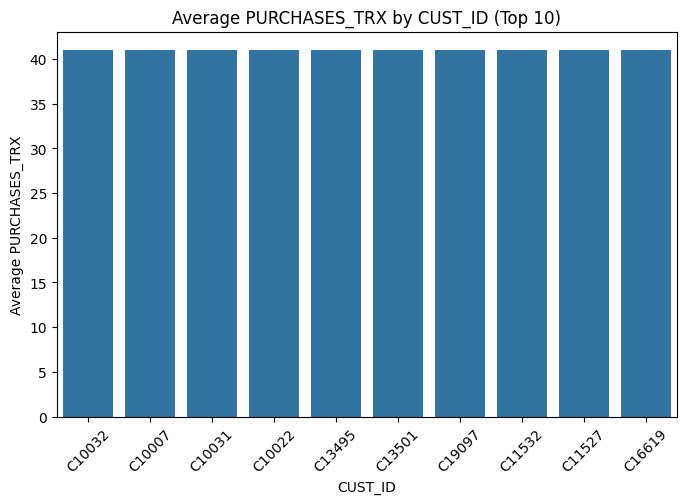


=== Average CREDIT_LIMIT for each CUST_ID ===
CUST_ID
C11786    13850.0
C10627    13850.0
C13610    13850.0
C15057    13850.0
C15056    13850.0
           ...   
C12567      150.0
C16725      150.0
C13566      150.0
C17140       50.0
C15349        NaN
Name: CREDIT_LIMIT, Length: 8950, dtype: float64


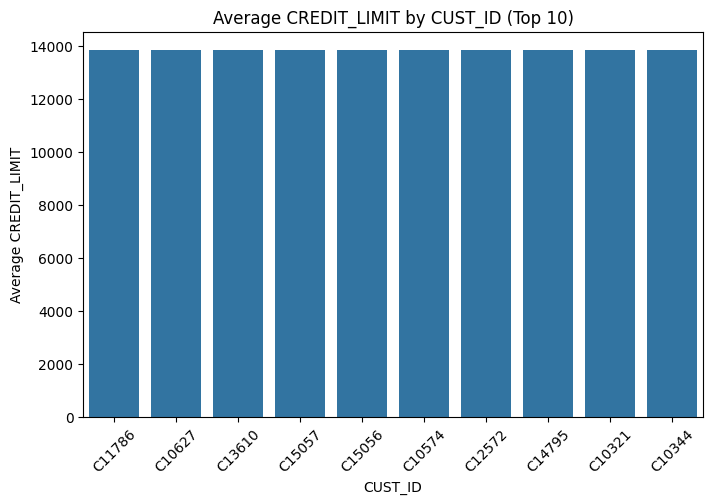


=== Average PAYMENTS for each CUST_ID ===
CUST_ID
C12005    4177.921543
C12006    4177.921543
C12014    4177.921543
C12016    4177.921543
C12024    4177.921543
             ...     
C10004       0.000000
C19160       0.000000
C19170       0.000000
C19176       0.000000
C19185       0.000000
Name: PAYMENTS, Length: 8950, dtype: float64


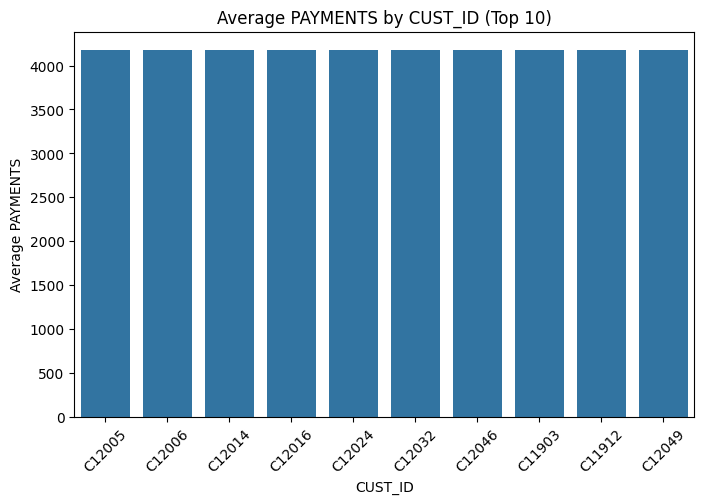


=== Average MINIMUM_PAYMENTS for each CUST_ID ===
CUST_ID
C19122    1810.028087
C10006    1810.028087
C10011    1810.028087
C12814    1810.028087
C19114    1810.028087
             ...     
C19160            NaN
C19170            NaN
C19176            NaN
C19185            NaN
C19187            NaN
Name: MINIMUM_PAYMENTS, Length: 8950, dtype: float64


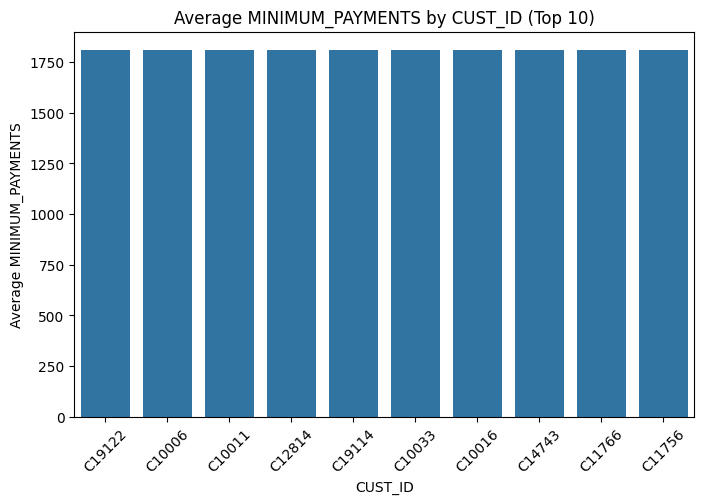


=== Average PRC_FULL_PAYMENT for each CUST_ID ===
CUST_ID
C10007    0.357143
C19186    0.357143
C19169    0.357143
C19167    0.357143
C19166    0.357143
            ...   
C19176    0.000000
C19174    0.000000
C19171    0.000000
C19170    0.000000
C19151    0.000000
Name: PRC_FULL_PAYMENT, Length: 8950, dtype: float64


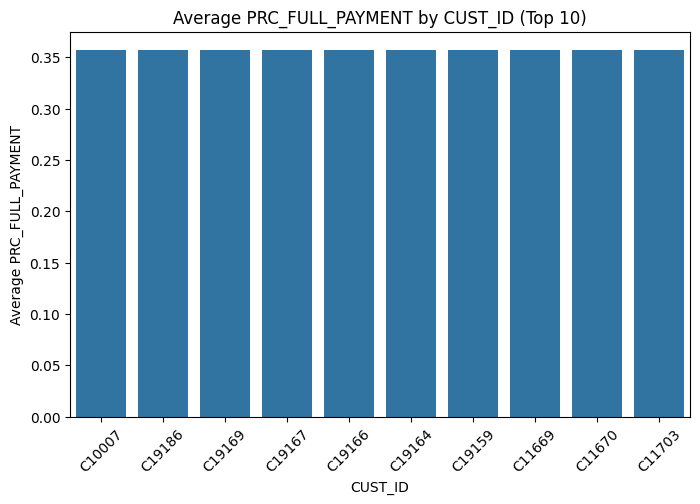


=== Average TENURE for each CUST_ID ===
CUST_ID
C10001    12.0
C10002    12.0
C10003    12.0
C10004    12.0
C10005    12.0
          ... 
C19186    12.0
C19187    12.0
C19188    12.0
C19189    12.0
C19190    12.0
Name: TENURE, Length: 8950, dtype: float64


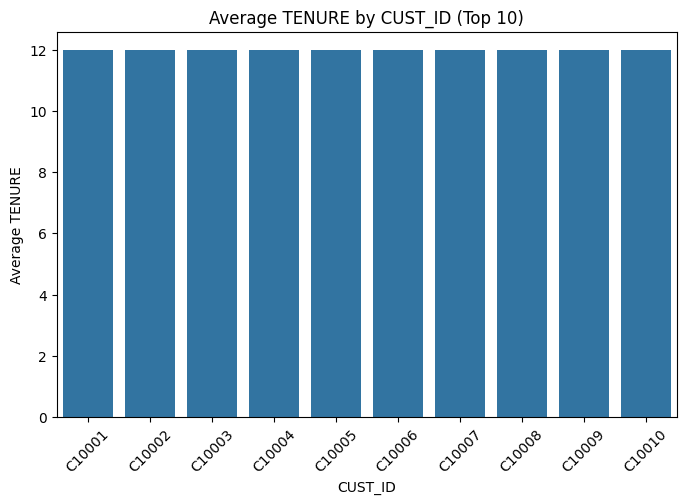

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for cat in cat_cols:
    for num in num_cols:
        print(f"\n=== Average {num} for each {cat} ===")
        
        # Group by categorical column and calculate mean
        result = df.groupby(cat)[num].mean().sort_values(ascending=False)
        print(result)
        
        # Plot (top 10 categories for readability)
        top_categories = result.head(10)
        
        plt.figure(figsize=(8,5))
        sns.barplot(x=top_categories.index, y=top_categories.values)
        plt.xticks(rotation=45)
        plt.title(f"Average {num} by {cat} (Top 10)")
        plt.xlabel(cat)
        plt.ylabel(f"Average {num}")
        plt.show()

Analyze the distribution of categorical variables conditioned on other categorical variables (e.g., how many customers with a high credit limit also have a high purchase frequency?).

=== Count Table ===
Purchase_Frequency_Category   Low  Medium  High
Credit_Limit_Category                          
Low                          1215     967   808
Medium                       1131    1105   825
High                          911     925  1062

=== Percentage Table ===
Purchase_Frequency_Category        Low     Medium       High
Credit_Limit_Category                                       
Low                          40.635452  32.341137  27.023411
Medium                       36.948710  36.099314  26.951976
High                         31.435473  31.918565  36.645963


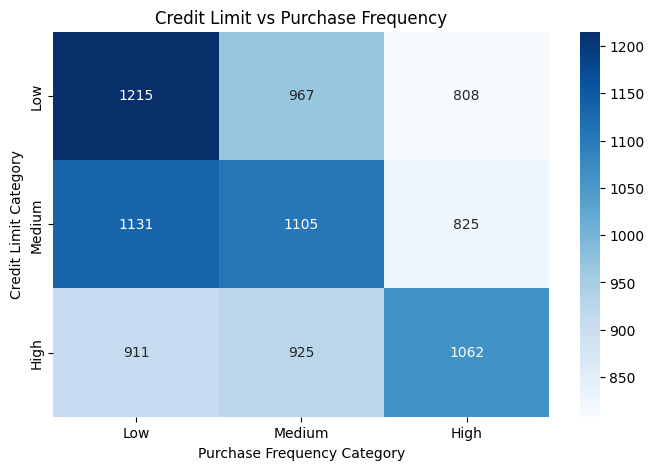

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Create categorical bins from numerical columns (if needed) ---
# Adjust column names based on your dataset
df['Credit_Limit_Category'] = pd.qcut(df['CREDIT_LIMIT'], q=3, labels=['Low', 'Medium', 'High'])
df['Purchase_Frequency_Category'] = pd.qcut(df['PURCHASES_FREQUENCY'], q=3, labels=['Low', 'Medium', 'High'])

# --- Cross-tabulation ---
crosstab = pd.crosstab(df['Credit_Limit_Category'], df['Purchase_Frequency_Category'])
print("=== Count Table ===")
print(crosstab)

# --- Percentage distribution ---
percentage = pd.crosstab(df['Credit_Limit_Category'], 
                        df['Purchase_Frequency_Category'], 
                        normalize='index') * 100
print("\n=== Percentage Table ===")
print(percentage)

# --- Heatmap visualization ---
plt.figure(figsize=(8,5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title("Credit Limit vs Purchase Frequency")
plt.xlabel("Purchase Frequency Category")
plt.ylabel("Credit Limit Category")
plt.show()


Explore the relationship between categorical variables and time-based features (e.g., how does the average purchase amount change over time for different customer segments?).

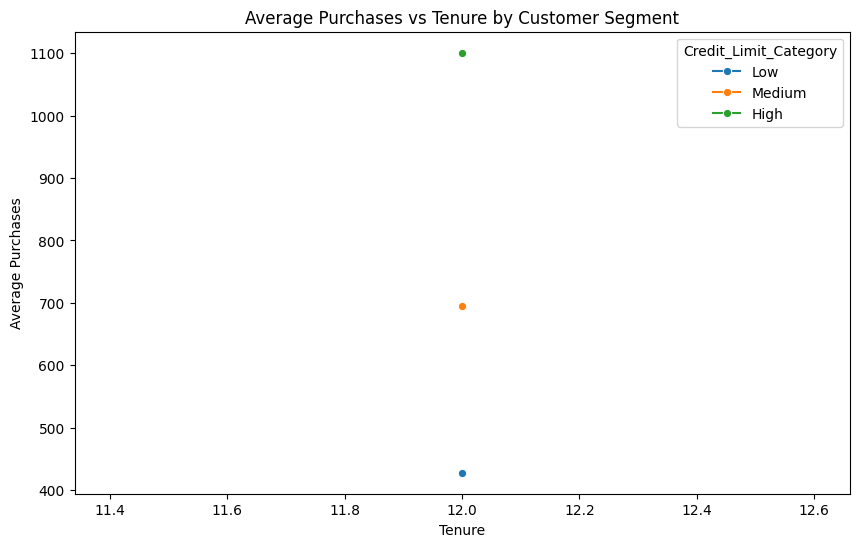

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create segments
df['Credit_Limit_Category'] = pd.qcut(df['CREDIT_LIMIT'], q=3, labels=['Low', 'Medium', 'High'])

# Group using TENURE (time-like feature)
result = df.groupby(['TENURE', 'Credit_Limit_Category'])['PURCHASES'].mean().reset_index()

# Plot
plt.figure(figsize=(10,6))
sns.lineplot(data=result, x='TENURE', y='PURCHASES', hue='Credit_Limit_Category', marker='o')

plt.title("Average Purchases vs Tenure by Customer Segment")
plt.xlabel("Tenure")
plt.ylabel("Average Purchases")
plt.show()

Identify any patterns or trends in the data that might be relevant for customer segmentation (e.g., are there specific groups of customers with similar purchasing behaviors?).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Select features
features = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS', 'TENURE']

# --- Step 1: Handle missing values ---
df_clean = df[features].copy()
df_clean = df_clean.fillna(df_clean.median())

# --- Step 2: Remove infinite values if any ---
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()

# --- Step 3: Scaling ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

# --- Step 4: KMeans ---
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# --- Step 5: Assign clusters back safely ---
df.loc[df_clean.index, 'Cluster'] = clusters

# --- Check result ---
print(df['Cluster'].value_counts())

Cluster
1.0    5884
0.0    1590
2.0    1476
Name: count, dtype: int64


Visualize the distribution of numerical variables using histograms or box plots to identify outliers or skewness in the data.

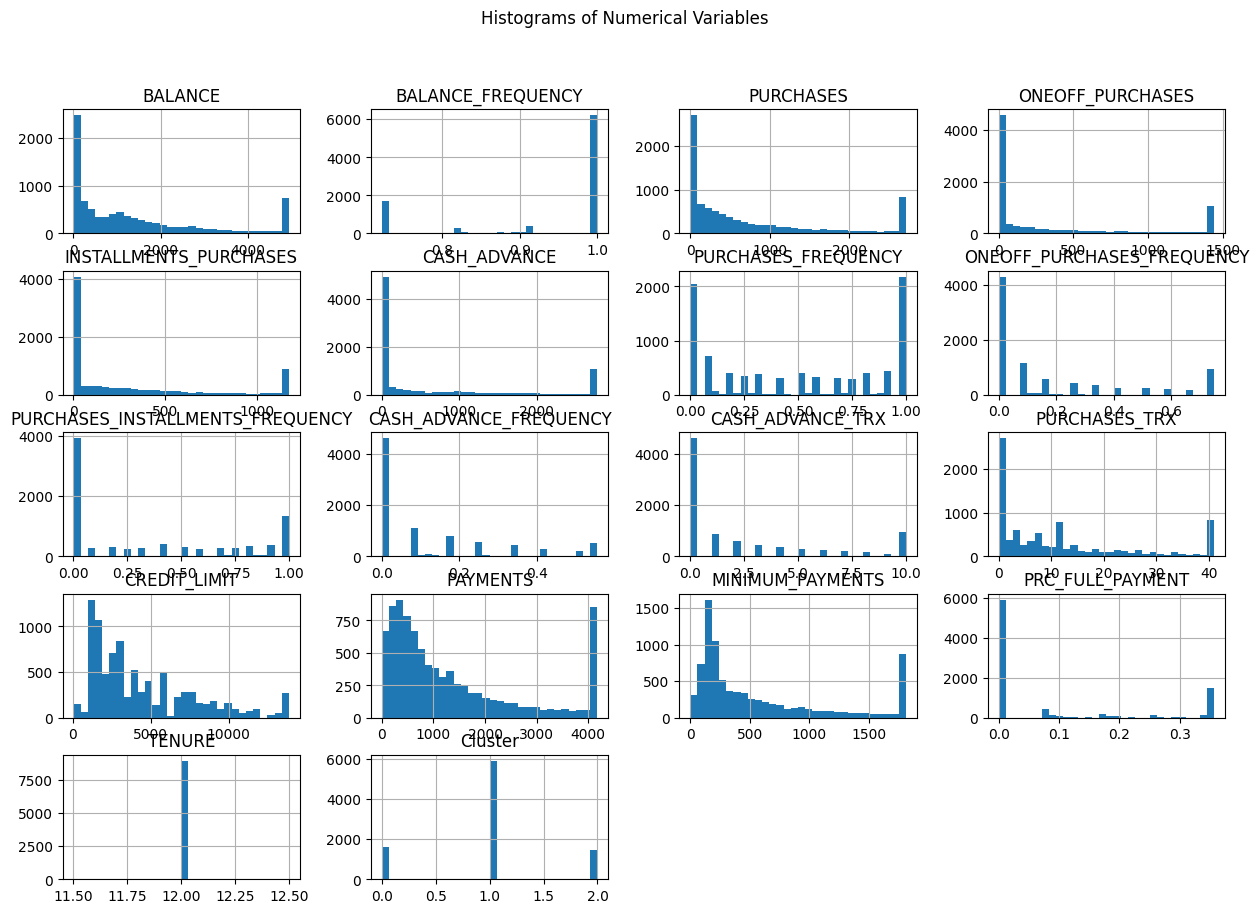

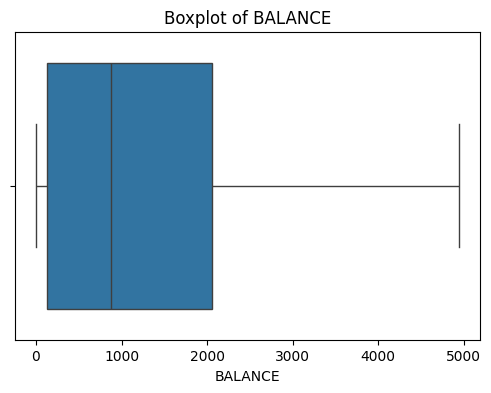

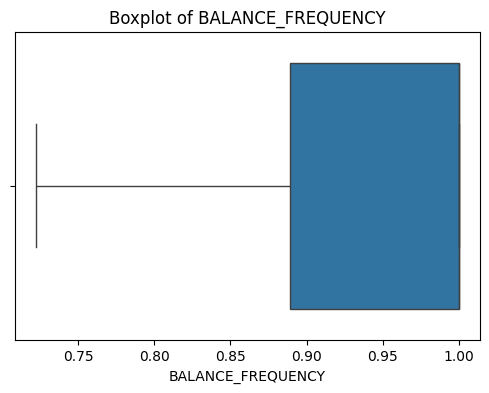

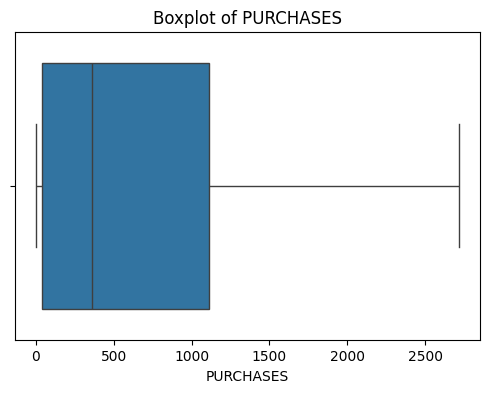

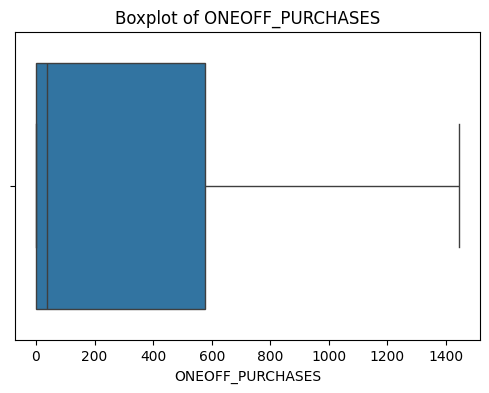

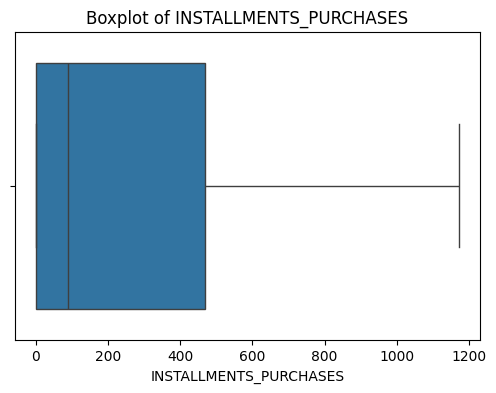

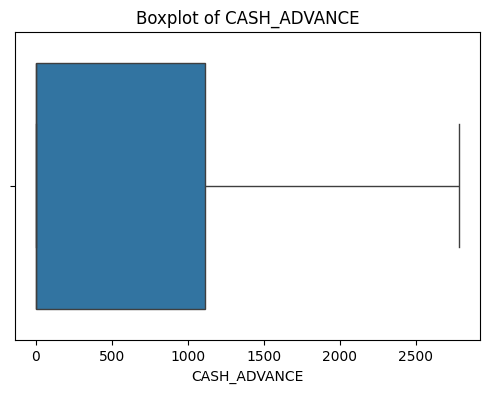

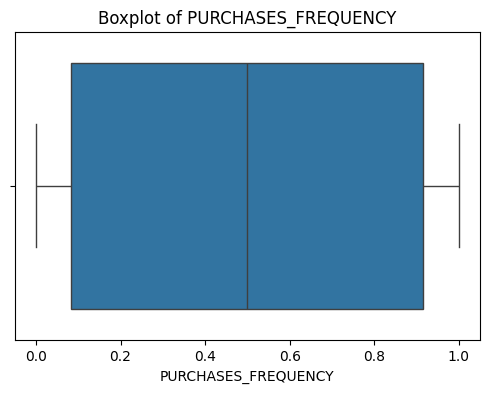

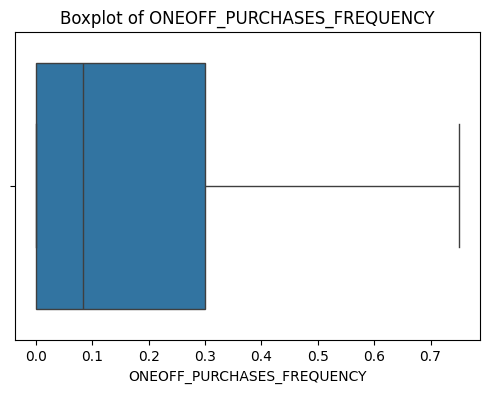

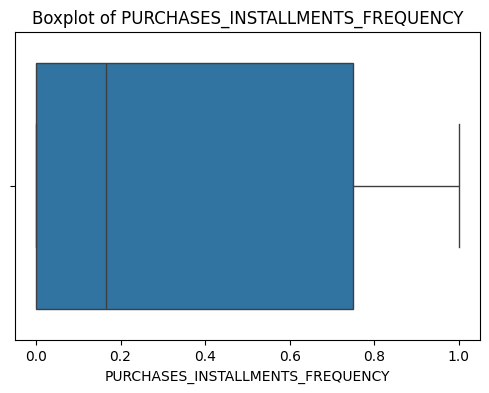

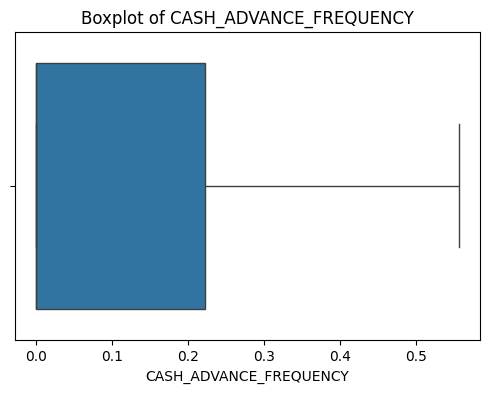

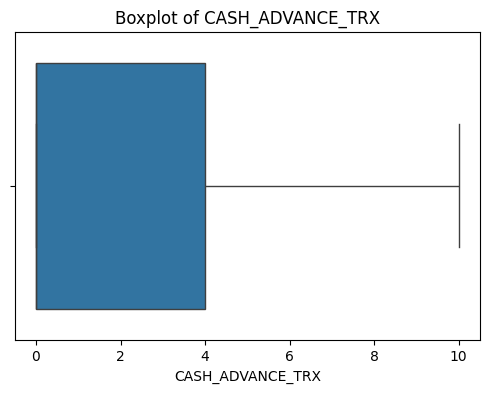

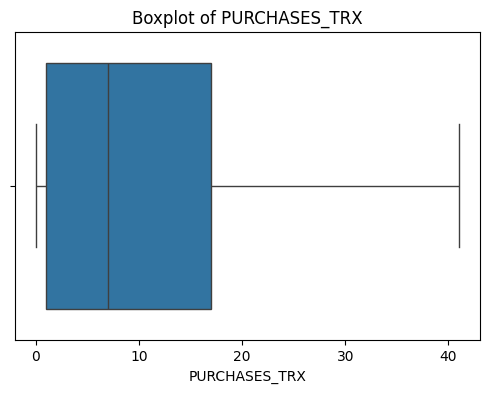

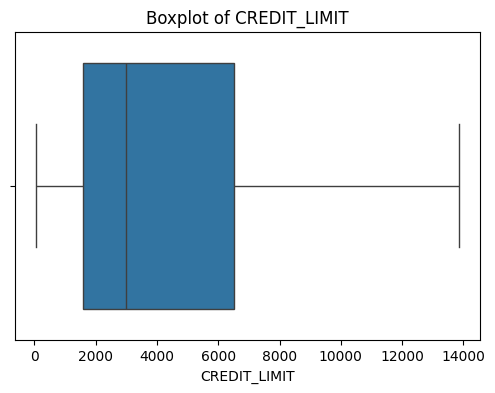

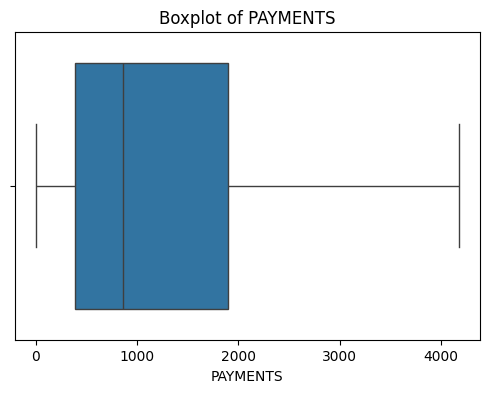

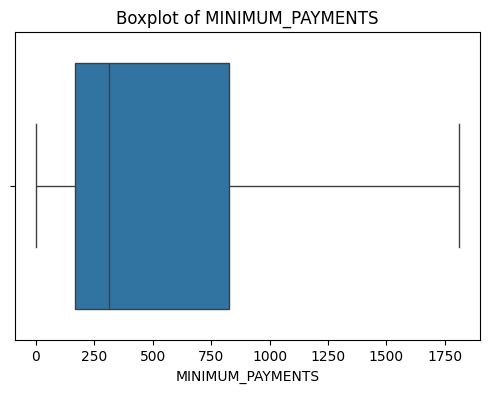

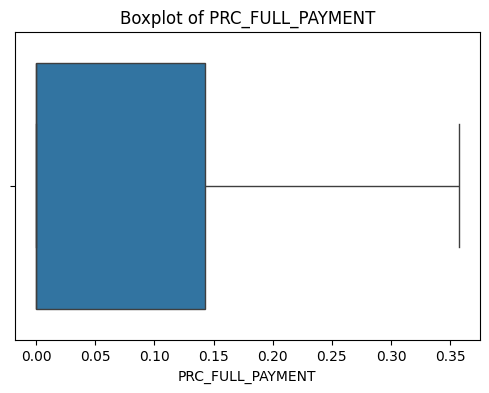

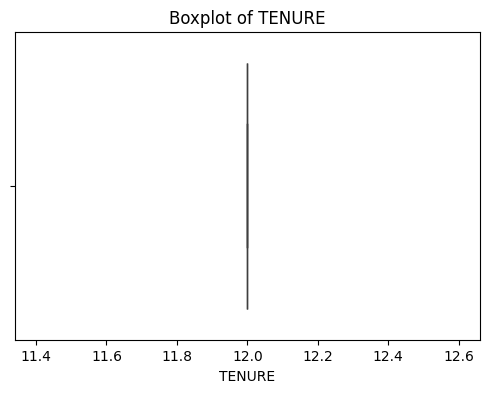

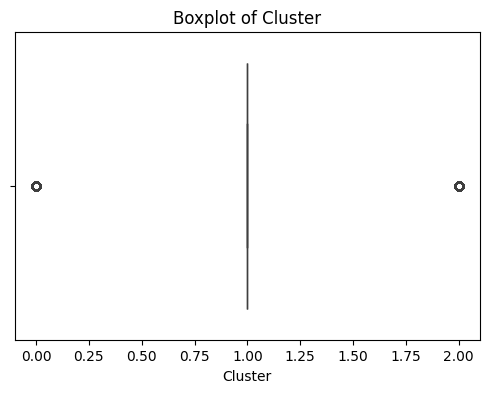

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# --- Histograms (distribution & skewness) ---
df[num_cols].hist(figsize=(15,10), bins=30)
plt.suptitle("Histograms of Numerical Variables")
plt.show()

# --- Boxplots (outliers detection) ---
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## EDA

Visualize the distribution of numerical variables: Create histograms, box plots, and density plots to understand the shape, central tendency, and spread of variables like BALANCE, PURCHASES, and ONEOFF_PURCHASES.

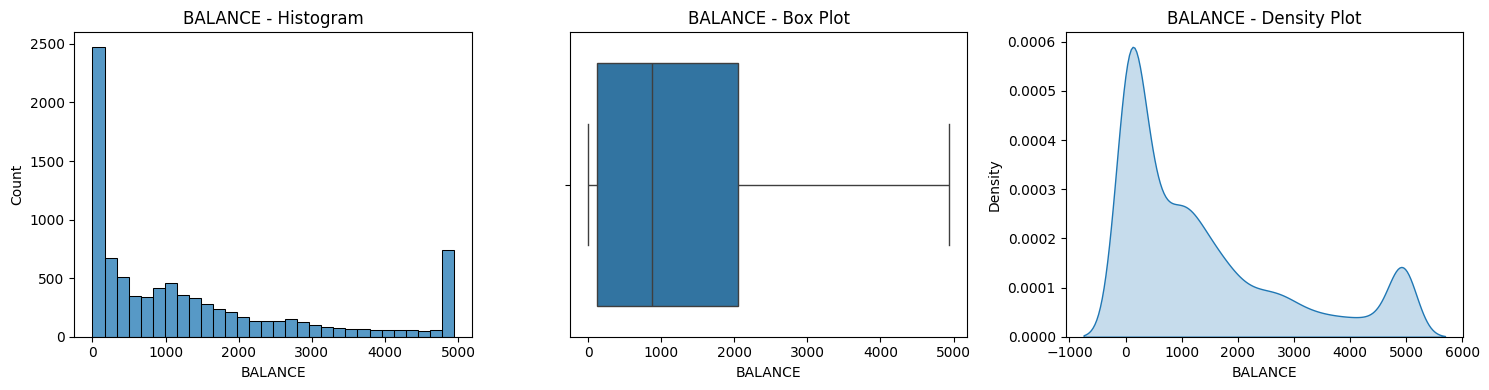

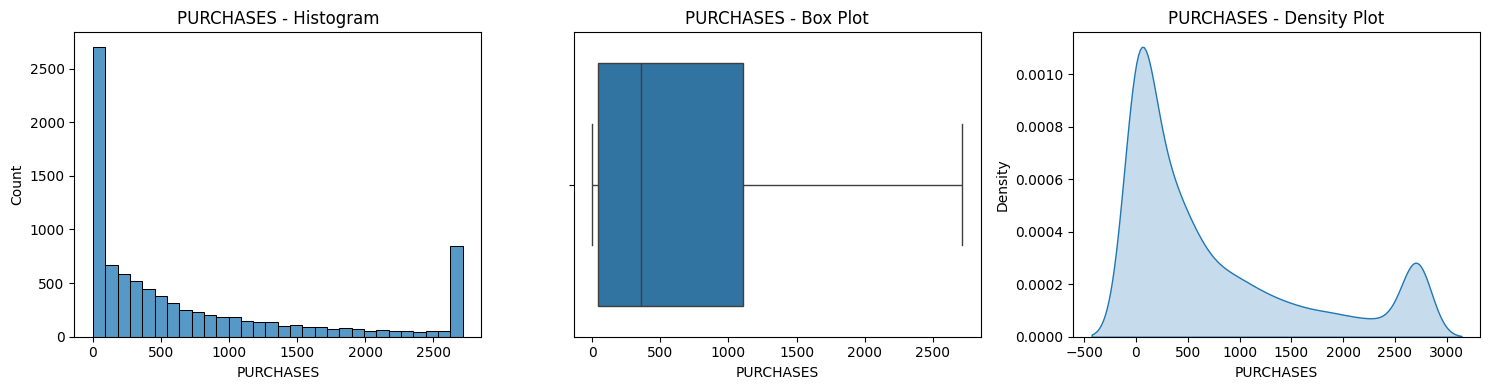

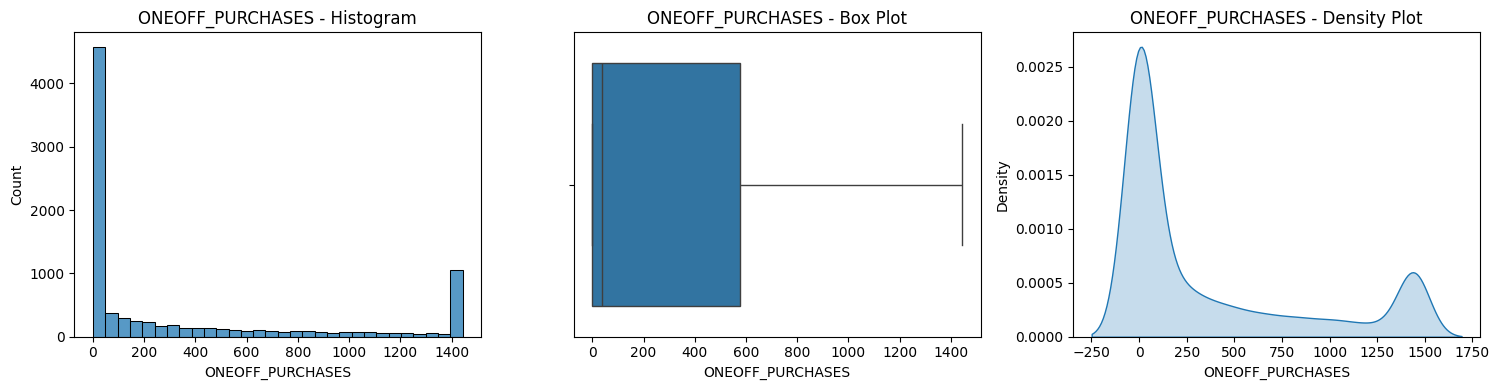

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select specific columns
cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES']

for col in cols:
    plt.figure(figsize=(15,4))
    
    # --- Histogram ---
    plt.subplot(1,3,1)
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f"{col} - Histogram")
    
    # --- Box Plot ---
    plt.subplot(1,3,2)
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Box Plot")
    
    # --- Density Plot ---
    plt.subplot(1,3,3)
    sns.kdeplot(df[col], fill=True)
    plt.title(f"{col} - Density Plot")
    
    plt.tight_layout()
    plt.show()

Visualize the distribution of categorical variables: Create bar charts or pie charts to show the frequency of different categories in variables like CUST_ID, PURCHASES_FREQUENCY, and CASHADVANCEFREQUENCY.

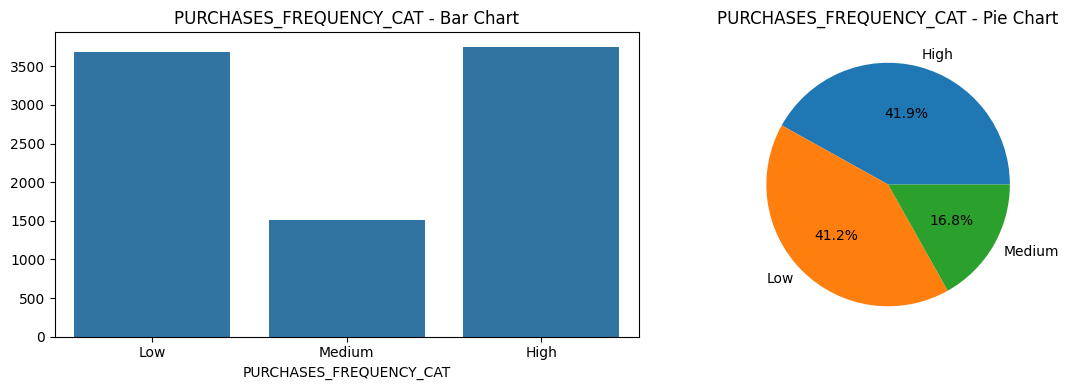

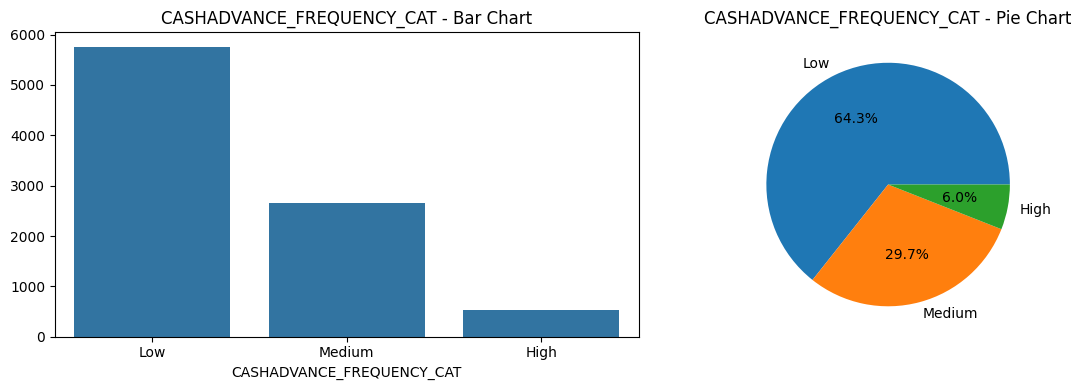

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Manual binning (works even with many zeros)
df['PURCHASES_FREQUENCY_CAT'] = pd.cut(
    df['PURCHASES_FREQUENCY'],
    bins=[-0.01, 0.33, 0.66, 1],
    labels=['Low', 'Medium', 'High']
)

df['CASHADVANCE_FREQUENCY_CAT'] = pd.cut(
    df['CASH_ADVANCE_FREQUENCY'],
    bins=[-0.01, 0.1, 0.5, 1],
    labels=['Low', 'Medium', 'High']
)

cat_cols = ['PURCHASES_FREQUENCY_CAT', 'CASHADVANCE_FREQUENCY_CAT']

for col in cat_cols:
    counts = df[col].value_counts()
    
    plt.figure(figsize=(12,4))
    
    # Bar chart
    plt.subplot(1,2,1)
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f"{col} - Bar Chart")
    
    # Pie chart
    plt.subplot(1,2,2)
    plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
    plt.title(f"{col} - Pie Chart")
    
    plt.tight_layout()
    plt.show()

Visualize the relationship between numerical variables: Create scatter plots to examine the correlation between pairs of numerical variables, such as BALANCE and PURCHASES.

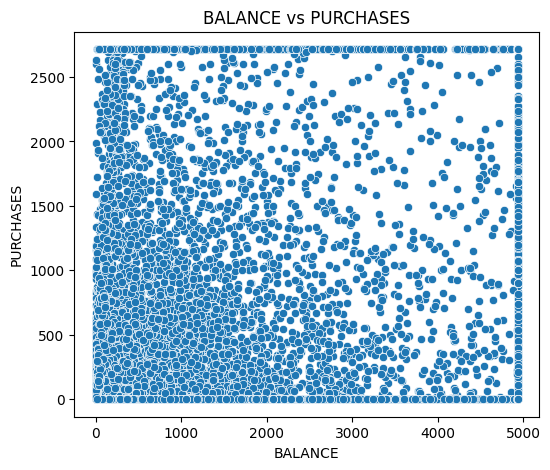

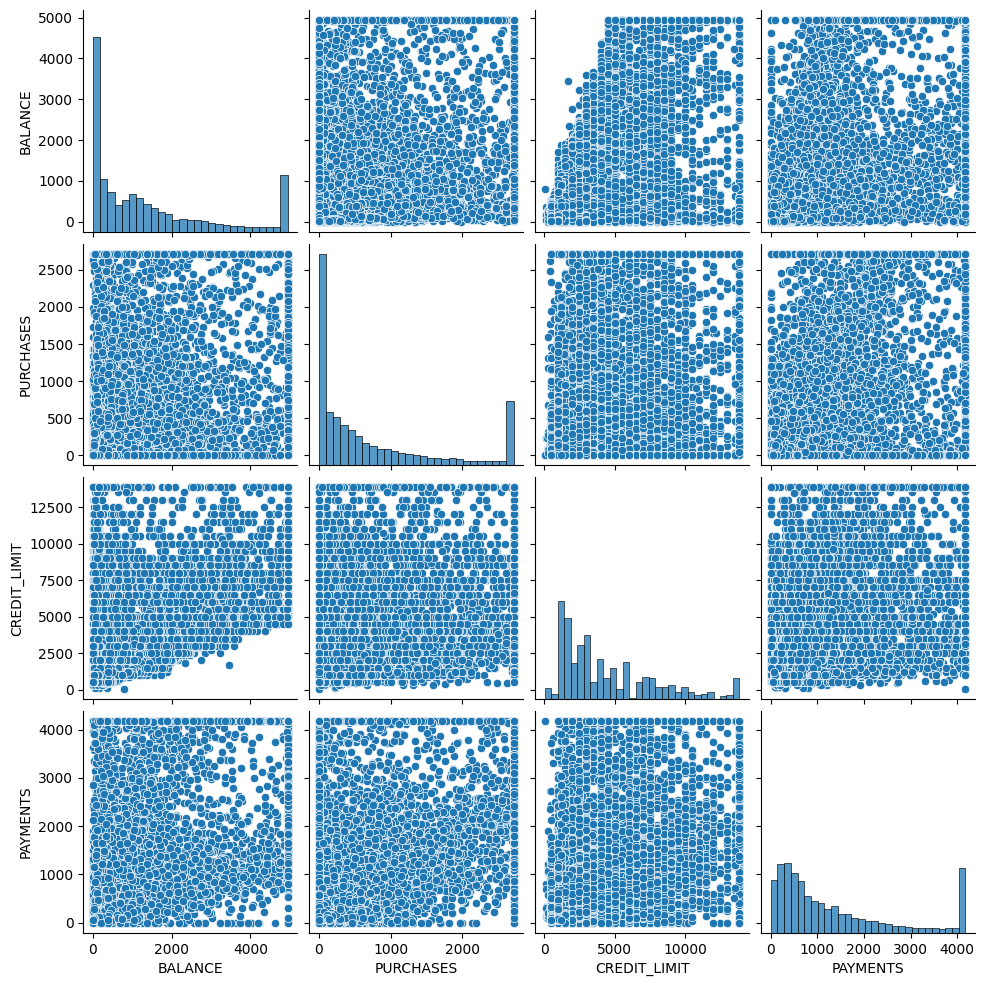

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# --- Specific scatter plot (BALANCE vs PURCHASES) ---
plt.figure(figsize=(6,5))
sns.scatterplot(x=df['BALANCE'], y=df['PURCHASES'])
plt.title("BALANCE vs PURCHASES")
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.show()

# --- Pairwise scatter plots (for multiple variables) ---
selected_cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']

sns.pairplot(df[selected_cols])
plt.show()

Visualize the relationship between categorical and numerical variables: Create box plots or violin plots to compare the distribution of a numerical variable across different categories of a categorical variable (e.g., compare the distribution of PURCHASES for different CUST_ID categories).

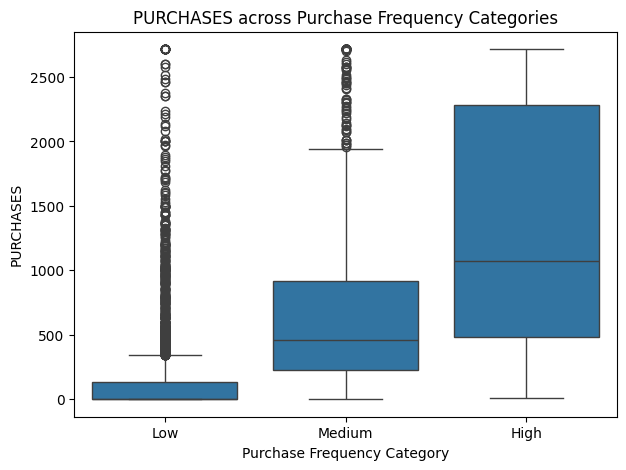

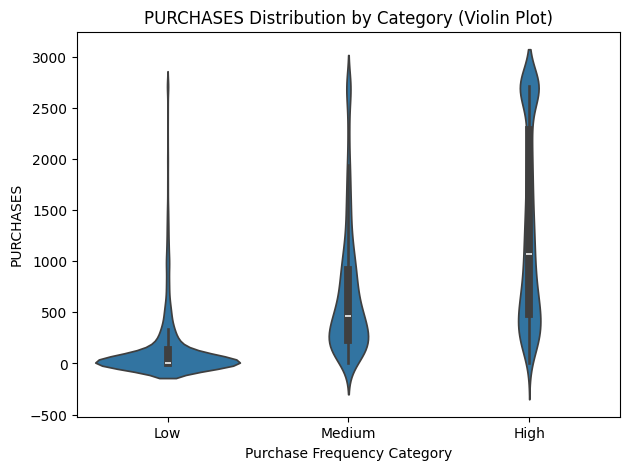

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create categorical variable (if not already created)
df['PURCHASES_FREQUENCY_CAT'] = pd.cut(
    df['PURCHASES_FREQUENCY'],
    bins=[-0.01, 0.33, 0.66, 1],
    labels=['Low', 'Medium', 'High']
)

# --- Box Plot ---
plt.figure(figsize=(7,5))
sns.boxplot(x=df['PURCHASES_FREQUENCY_CAT'], y=df['PURCHASES'])
plt.title("PURCHASES across Purchase Frequency Categories")
plt.xlabel("Purchase Frequency Category")
plt.ylabel("PURCHASES")
plt.show()

# --- Violin Plot ---
plt.figure(figsize=(7,5))
sns.violinplot(x=df['PURCHASES_FREQUENCY_CAT'], y=df['PURCHASES'])
plt.title("PURCHASES Distribution by Category (Violin Plot)")
plt.xlabel("Purchase Frequency Category")
plt.ylabel("PURCHASES")
plt.show()

Visualize the relationship between multiple variables: Create pair plots or correlation matrices to explore the relationships between multiple variables simultaneously.

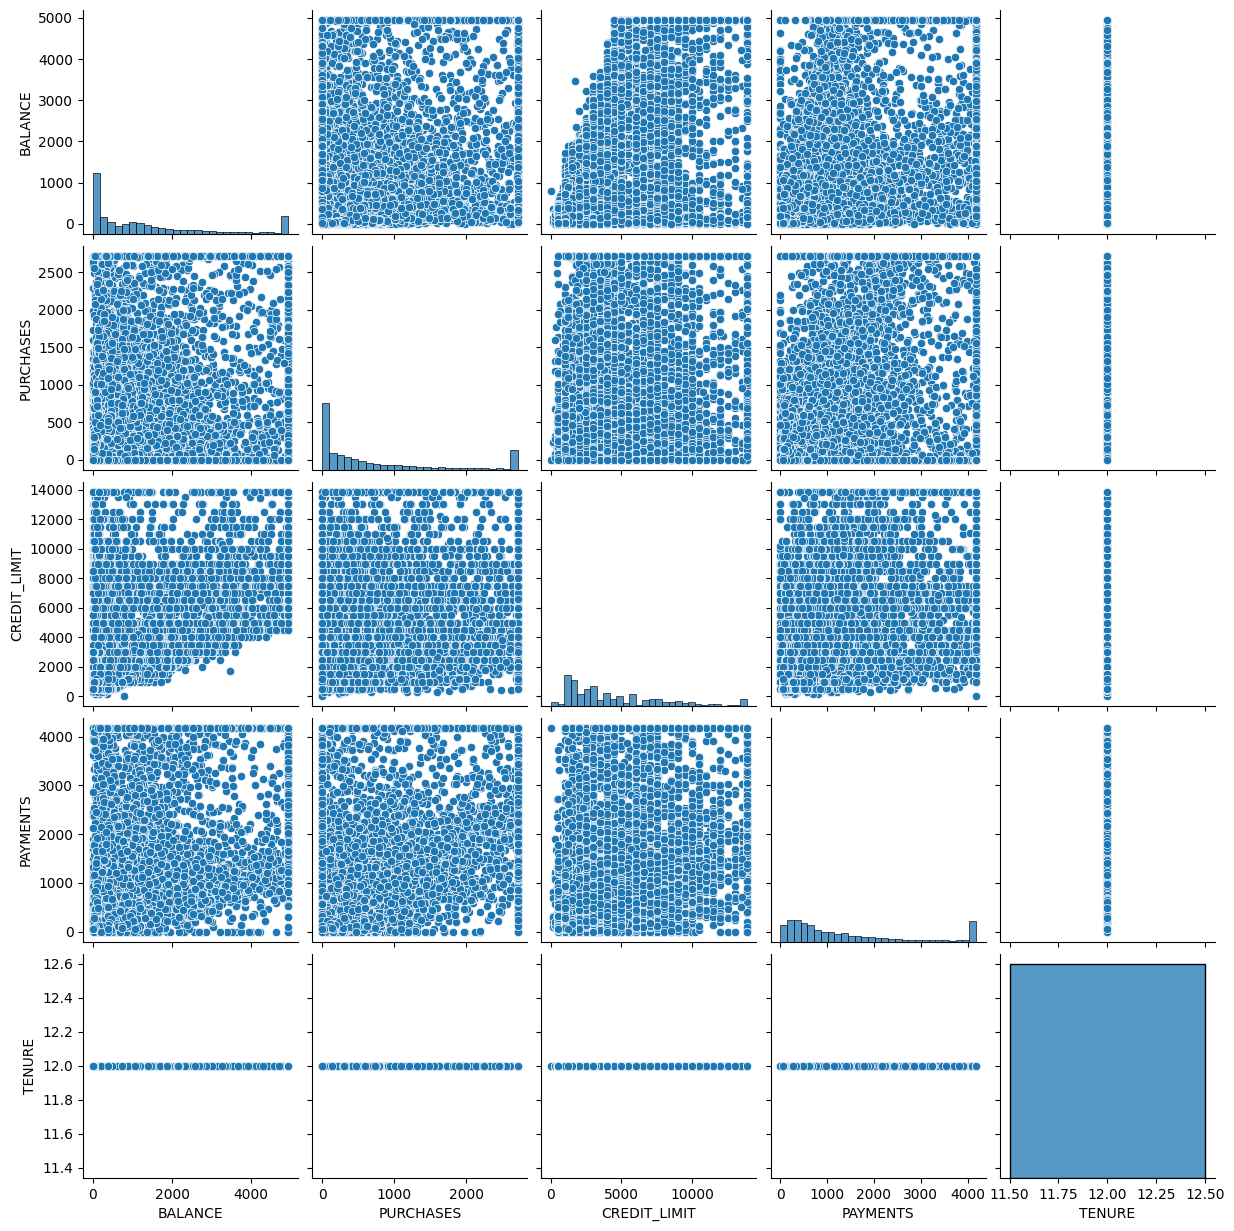

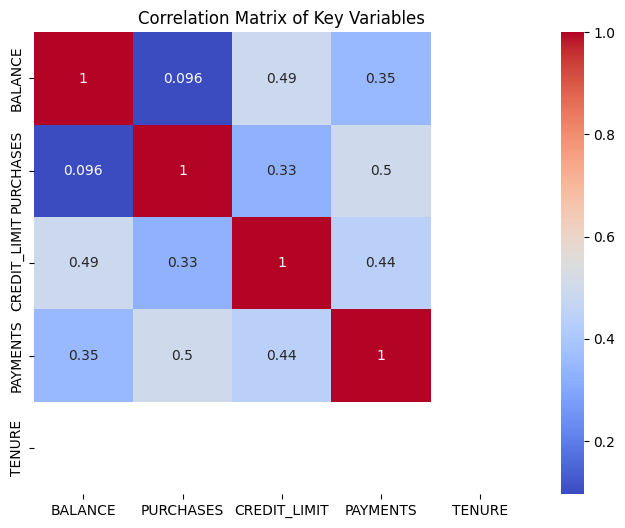

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select important numerical features
features = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS', 'TENURE']

# --- Pair Plot (multi-variable relationships) ---
sns.pairplot(df[features])
plt.show()

# --- Correlation Matrix ---
corr_matrix = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Key Variables")
plt.show()

Visualize interactions between variables: Create interaction plots to examine how the relationship between two variables changes depending on the value of a third variable.

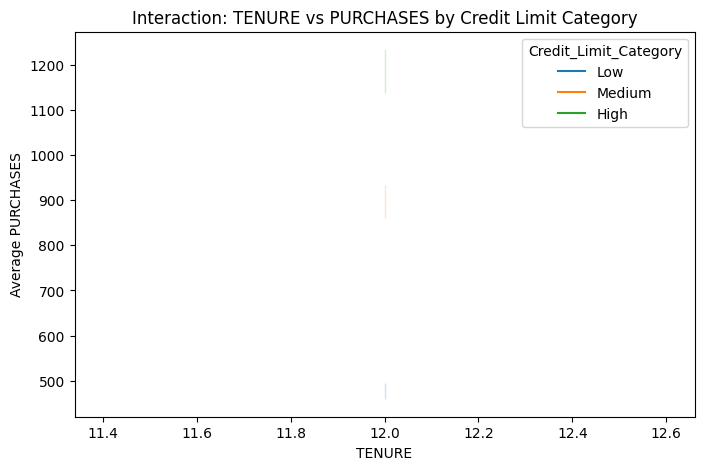

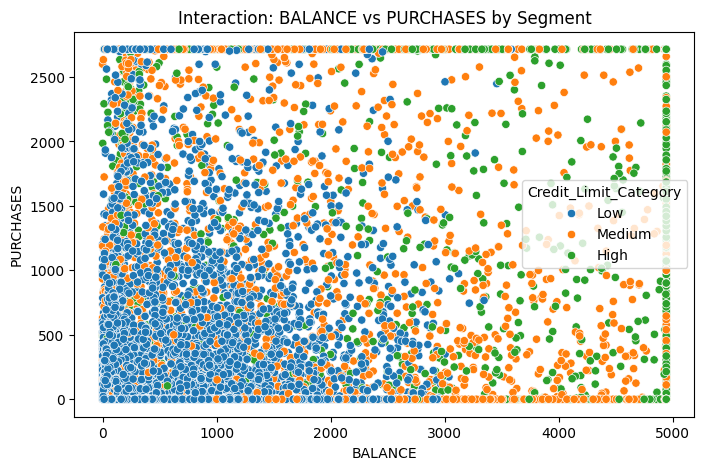

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a categorical segment (third variable)
df['Credit_Limit_Category'] = pd.cut(
    df['CREDIT_LIMIT'],
    bins=[-1, 3000, 7000, df['CREDIT_LIMIT'].max()],
    labels=['Low', 'Medium', 'High']
)

# --- Interaction Plot (Line plot style) ---
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x='TENURE',                 # Variable 1
    y='PURCHASES',              # Variable 2
    hue='Credit_Limit_Category',# Variable 3 (interaction)
    estimator='mean'
)

plt.title("Interaction: TENURE vs PURCHASES by Credit Limit Category")
plt.xlabel("TENURE")
plt.ylabel("Average PURCHASES")
plt.show()

# --- Alternative: Scatter with interaction ---
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='BALANCE',
    y='PURCHASES',
    hue='Credit_Limit_Category'
)

plt.title("Interaction: BALANCE vs PURCHASES by Segment")
plt.show()

Visualize trends over time: Create line charts to plot numerical variables against time (if applicable), such as the evolution of BALANCE or PURCHASES over the last 6 months.

   TENURE      BALANCE  PURCHASES
0    12.0  1390.508973  737.14933


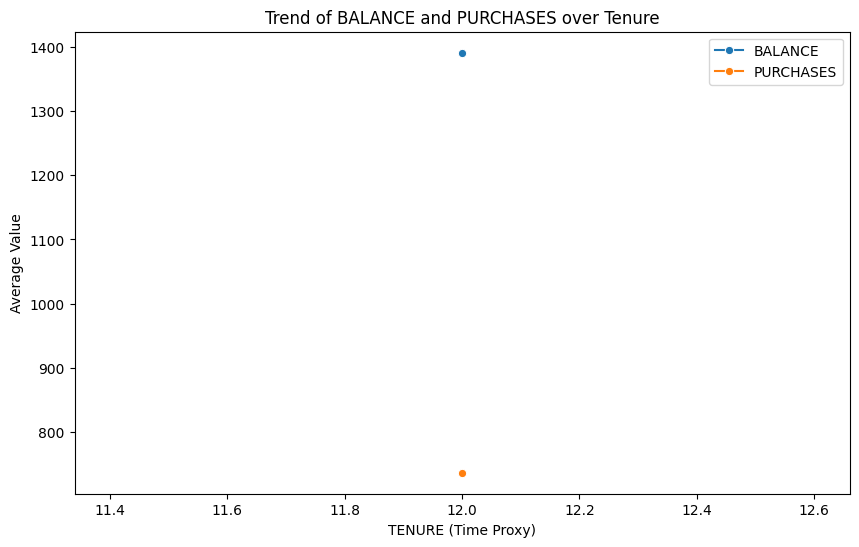

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Group data by TENURE (acts like time) ---
trend = df.groupby('TENURE')[['BALANCE', 'PURCHASES']].mean().reset_index()

print(trend.head())

# --- Line plot ---
plt.figure(figsize=(10,6))

sns.lineplot(data=trend, x='TENURE', y='BALANCE', marker='o', label='BALANCE')
sns.lineplot(data=trend, x='TENURE', y='PURCHASES', marker='o', label='PURCHASES')

plt.title("Trend of BALANCE and PURCHASES over Tenure")
plt.xlabel("TENURE (Time Proxy)")
plt.ylabel("Average Value")
plt.legend()
plt.show()

Visualize seasonal patterns: Create seasonal decomposition plots to identify seasonal trends, cyclical patterns, and residuals in time-based data.

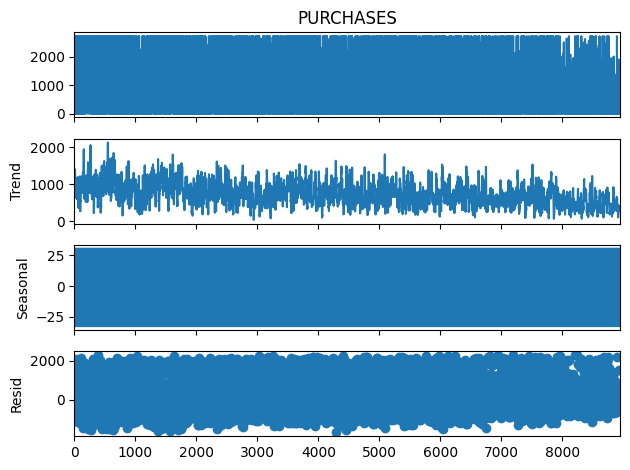

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Sort by TENURE
df_sorted = df.sort_values('TENURE')

# Use PURCHASES directly
series = df_sorted['PURCHASES']

# Apply decomposition (use larger period)
result = seasonal_decompose(series, model='additive', period=10)

result.plot()
plt.show()

Visualize the distribution of credit limits: Create a histogram or box plot to understand the distribution of credit limits among customers. Are there any significant differences in credit limits between different customer segments?

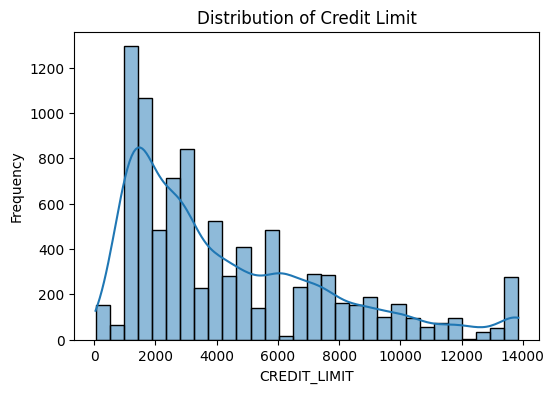

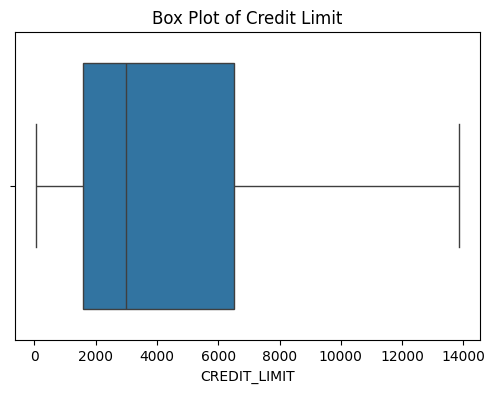

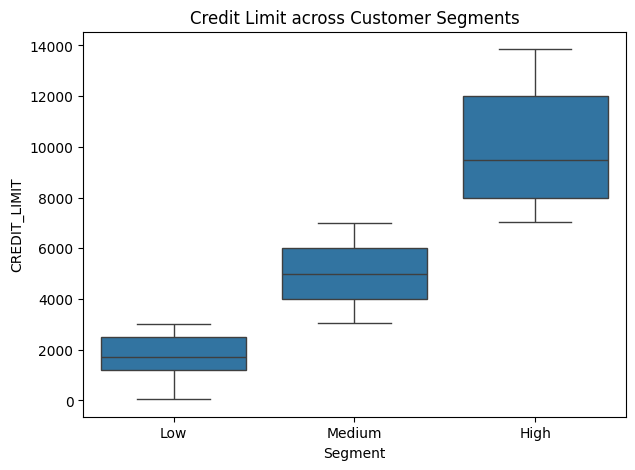

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Histogram ---
plt.figure(figsize=(6,4))
sns.histplot(df['CREDIT_LIMIT'], bins=30, kde=True)
plt.title("Distribution of Credit Limit")
plt.xlabel("CREDIT_LIMIT")
plt.ylabel("Frequency")
plt.show()

# --- Box Plot (overall) ---
plt.figure(figsize=(6,4))
sns.boxplot(x=df['CREDIT_LIMIT'])
plt.title("Box Plot of Credit Limit")
plt.show()

# --- Create customer segments ---
df['Credit_Limit_Category'] = pd.cut(
    df['CREDIT_LIMIT'],
    bins=[-1, 3000, 7000, df['CREDIT_LIMIT'].max()],
    labels=['Low', 'Medium', 'High']
)

# --- Compare across segments ---
plt.figure(figsize=(7,5))
sns.boxplot(x=df['Credit_Limit_Category'], y=df['CREDIT_LIMIT'])
plt.title("Credit Limit across Customer Segments")
plt.xlabel("Segment")
plt.ylabel("CREDIT_LIMIT")
plt.show()

Visualize the relationship between payment patterns and delinquency: Create a scatter plot to examine the relationship between the percentage of full payments made (PRCFULLPAYMENT) and the number of times the minimum payment was not made (MINIMUM_PAYMENTS). Are there any patterns indicating which customers are more likely to be delinquent?

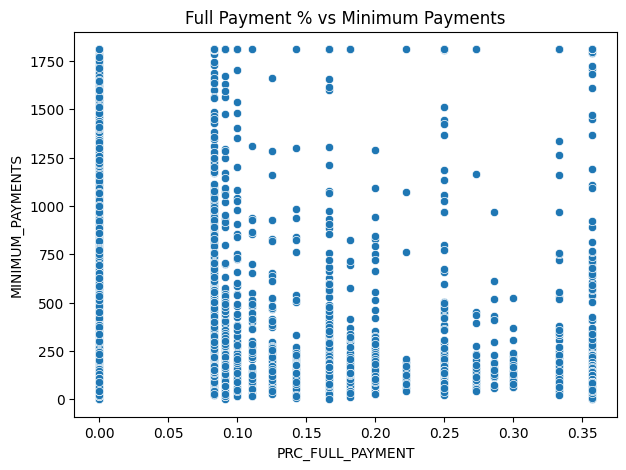

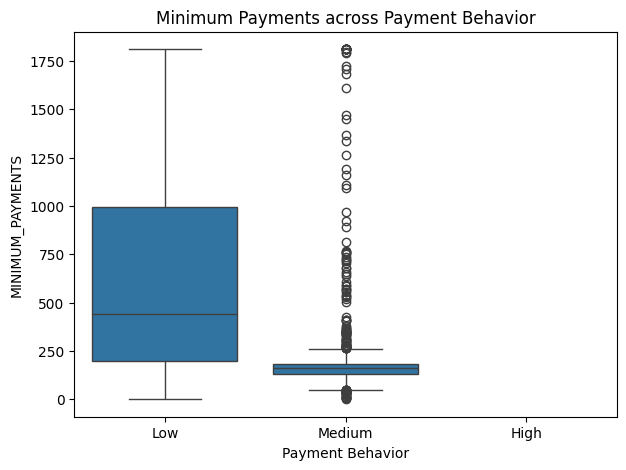

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Scatter Plot ---
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['PRC_FULL_PAYMENT'], 
    y=df['MINIMUM_PAYMENTS']
)

plt.title("Full Payment % vs Minimum Payments")
plt.xlabel("PRC_FULL_PAYMENT")
plt.ylabel("MINIMUM_PAYMENTS")
plt.show()

# --- Optional: Create risk categories for better insight ---
df['Payment_Behavior'] = pd.cut(
    df['PRC_FULL_PAYMENT'],
    bins=[-0.01, 0.3, 0.7, 1],
    labels=['Low', 'Medium', 'High']
)

# --- Boxplot for clearer comparison ---
plt.figure(figsize=(7,5))
sns.boxplot(x=df['Payment_Behavior'], y=df['MINIMUM_PAYMENTS'])
plt.title("Minimum Payments across Payment Behavior")
plt.xlabel("Payment Behavior")
plt.ylabel("MINIMUM_PAYMENTS")
plt.show()

Visualize the distribution of tenure: Create a histogram or bar chart to understand the distribution of credit card tenure among customers. Are there any significant differences in tenure between different customer segments?

In [ ]:
# Safe dynamic binning
df['Spending_Category'] = pd.cut(
    df['PURCHASES'],
    bins=[df['PURCHASES'].min()-1,
          df['PURCHASES'].quantile(0.33),
          df['PURCHASES'].quantile(0.66),
          df['PURCHASES'].max()],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

Visualize the relationship between purchase frequency and purchase amount: Create a scatter plot to examine the relationship between the frequency of purchases (PURCHASES_FREQUENCY) and the total purchase amount (PURCHASES). Are there any patterns indicating which customers are more likely to make larger purchases?

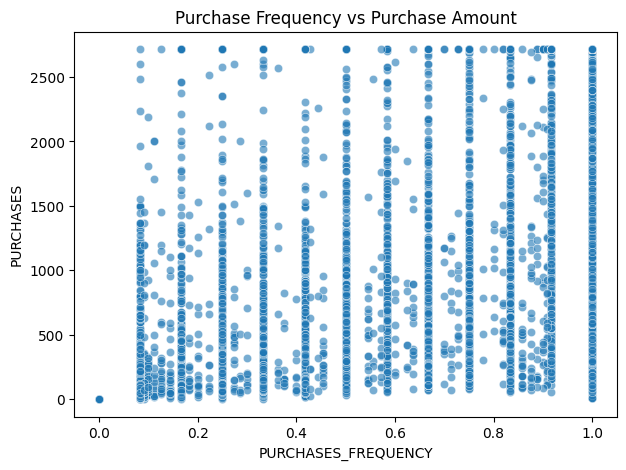

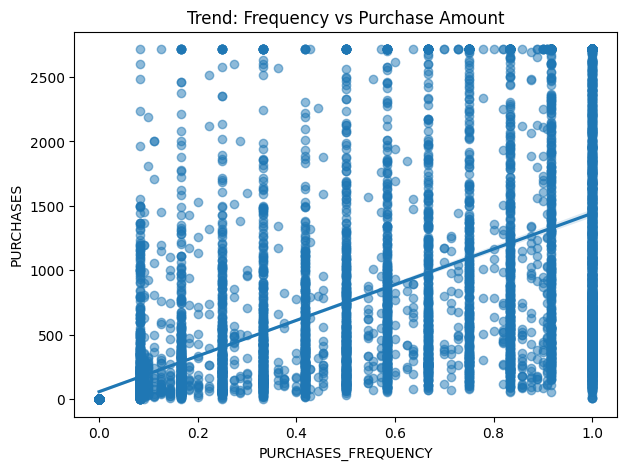

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scatter Plot ---
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['PURCHASES_FREQUENCY'],
    y=df['PURCHASES'],
    alpha=0.6
)

plt.title("Purchase Frequency vs Purchase Amount")
plt.xlabel("PURCHASES_FREQUENCY")
plt.ylabel("PURCHASES")
plt.show()

# --- Optional: Add trend line for better insight ---
plt.figure(figsize=(7,5))
sns.regplot(
    x=df['PURCHASES_FREQUENCY'],
    y=df['PURCHASES'],
    scatter_kws={'alpha':0.5}
)

plt.title("Trend: Frequency vs Purchase Amount")
plt.xlabel("PURCHASES_FREQUENCY")
plt.ylabel("PURCHASES")
plt.show()

Visualize the relationship between cash advance usage and purchase behavior: Create a scatter plot to examine the relationship between the amount of cash advances (CASH_ADVANCE) and the total purchase amount (PURCHASES). Are there any patterns indicating which customers are more likely to use cash advances and how this affects their purchase behavior?

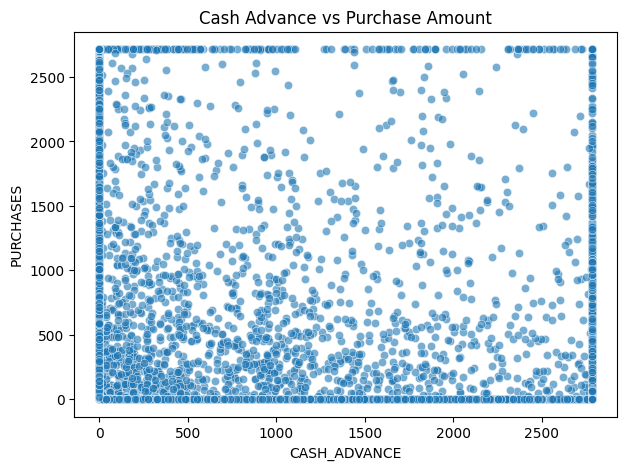

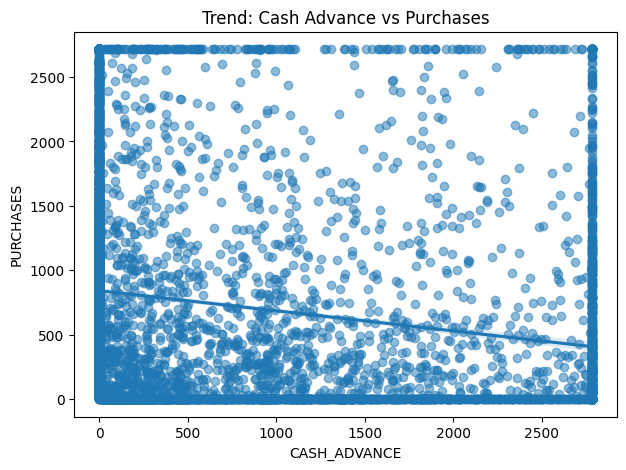

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scatter Plot ---
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df['CASH_ADVANCE'],
    y=df['PURCHASES'],
    alpha=0.6
)

plt.title("Cash Advance vs Purchase Amount")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PURCHASES")
plt.show()

# --- Add trend line ---
plt.figure(figsize=(7,5))
sns.regplot(
    x=df['CASH_ADVANCE'],
    y=df['PURCHASES'],
    scatter_kws={'alpha':0.5}
)

plt.title("Trend: Cash Advance vs Purchases")
plt.xlabel("CASH_ADVANCE")
plt.ylabel("PURCHASES")
plt.show()

## Data Preprocessing

Scale numerical variables to a common range (e.g., 0-1 or -1 to 1) using techniques like min-max scaling or standardization to improve model performance and prevent numerical instability.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns (exclude ID / categorical)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('CUST_ID', errors='ignore')  # remove ID if present

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# View result
df_scaled.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Credit_Limit_Category,Purchase_Frequency_Category,Cluster,PURCHASES_FREQUENCY_CAT,CASHADVANCE_FREQUENCY_CAT,Payment_Behavior,Spending_Category
0,C10001,-0.877821,-1.021875,-0.729687,-0.692383,-0.505216,-0.673507,-0.806490,-0.722749,-0.707313,-0.730084,-0.697293,-0.737970,-1.010503,-0.899859,-0.777496,-0.629277,0.0,Low,Low,0.021768,Low,Low,Low,Low
1,C10002,1.178546,-0.202708,-0.838160,-0.692383,-0.746029,2.115343,-1.221758,-0.722749,-0.916995,0.717792,0.473089,-0.891333,0.762675,2.165375,0.887294,0.973961,0.0,Medium,Low,1.730713,Low,Medium,Low,Low
2,C10003,0.718487,0.616459,0.040957,0.818320,-0.746029,-0.673507,1.269843,2.210909,-0.916995,-0.730084,-0.697293,0.028848,0.910439,-0.569653,0.093019,-0.629277,0.0,High,High,1.730713,High,Low,Low,High
3,C10004,0.179623,-1.886552,0.866246,2.128108,-0.746029,-0.467401,-1.014125,-0.396788,-0.916995,-0.247460,-0.404697,-0.814651,0.910439,-1.058417,NaN,-0.629277,0.0,High,Low,0.021768,Low,Low,Low,High
4,C10005,-0.372561,0.616459,-0.819967,-0.661121,-0.746029,-0.673507,-1.014125,-0.396788,-0.916995,-0.730084,-0.697293,-0.814651,-0.951397,-0.525443,-0.589604,-0.629277,0.0,Low,Low,0.021768,Low,Low,Low,Low


Convert categorical variables to numerical representations using techniques like one-hot encoding or label encoding, depending on the nature of the variables.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# --- Identify categorical columns ---
cat_cols = df_encoded.select_dtypes(include=['object']).columns

# --- Separate ID column if present ---
cat_cols = cat_cols.drop('CUST_ID', errors='ignore')

# --- 1. One-Hot Encoding (for nominal categories) ---
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=True)

# --- 2. Label Encoding (only for ID or ordinal columns if needed) ---
if 'CUST_ID' in df.columns:
    le = LabelEncoder()
    df_encoded['CUST_ID'] = le.fit_transform(df['CUST_ID'])

# --- View result ---
df_encoded.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Credit_Limit_Category,Purchase_Frequency_Category,Cluster,PURCHASES_FREQUENCY_CAT,CASHADVANCE_FREQUENCY_CAT,Payment_Behavior,Spending_Category
0,0,40.900749,0.818182,95.40,0.0000,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low
1,1,3202.467416,0.909091,0.00,0.0000,0.0,2784.552848,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,Medium,Low,2.0,Low,Medium,Low,Low
2,2,2495.148862,1.000000,773.17,773.1700,0.0,0.000000,1.000000,0.750000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,High,High,2.0,High,Low,Low,High
3,3,1666.670542,0.722223,1499.00,1443.5125,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,NaN,0.000000,12.0,High,Low,1.0,Low,Low,Low,High
4,4,817.714335,1.000000,16.00,16.0000,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low


## Feature Engineering

Combine existing features to capture interactions between them (e.g., multiply BALANCE and PURCHASES_FREQUENCY to create a new feature representing the total spending per unit time).

In [ ]:
import pandas as pd

df_fe = df.copy()

# --- Spending intensity (your example) ---
df_fe['SPENDING_INTENSITY'] = df_fe['BALANCE'] * df_fe['PURCHASES_FREQUENCY']

# --- Average purchase value ---
df_fe['AVG_PURCHASE_VALUE'] = df_fe['PURCHASES'] / (df_fe['PURCHASES_FREQUENCY'] + 1e-5)

# --- Cash usage ratio ---
df_fe['CASH_USAGE_RATIO'] = df_fe['CASH_ADVANCE'] / (df_fe['PURCHASES'] + 1e-5)

# --- Credit utilization ---
df_fe['CREDIT_UTILIZATION'] = df_fe['BALANCE'] / (df_fe['CREDIT_LIMIT'] + 1e-5)

# --- Payment behavior score ---
df_fe['PAYMENT_SCORE'] = df_fe['PRC_FULL_PAYMENT'] * df_fe['TENURE']

# --- Purchase per tenure (loyalty spending) ---
df_fe['PURCHASE_PER_TENURE'] = df_fe['PURCHASES'] / (df_fe['TENURE'] + 1e-5)

# View new features
df_fe.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Credit_Limit_Category,Purchase_Frequency_Category,Cluster,PURCHASES_FREQUENCY_CAT,CASHADVANCE_FREQUENCY_CAT,Payment_Behavior,Spending_Category,SPENDING_INTENSITY,AVG_PURCHASE_VALUE,CASH_USAGE_RATIO,CREDIT_UTILIZATION,PAYMENT_SCORE,PURCHASE_PER_TENURE
0,C10001,40.900749,0.818182,95.40,0.0000,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,6.816805,572.364513,0.000000e+00,0.040901,0.000000,7.949993
1,C10002,3202.467416,0.909091,0.00,0.0000,0.0,2784.552848,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,Medium,Low,2.0,Low,Medium,Low,Low,0.000000,0.000000,2.784553e+08,0.457495,2.666664,0.000000
2,C10003,2495.148862,1.000000,773.17,773.1700,0.0,0.000000,1.000000,0.750000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,High,High,2.0,High,Low,Low,High,2495.148862,773.162268,0.000000e+00,0.332687,0.000000,64.430780
3,C10004,1666.670542,0.722223,1499.00,1443.5125,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,NaN,0.000000,12.0,High,Low,1.0,Low,Low,Low,High,138.888656,17985.913634,1.372835e-01,0.222223,0.000000,124.916563
4,C10005,817.714335,1.000000,16.00,16.0000,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,68.142589,191.977731,0.000000e+00,0.681429,0.000000,1.333332


Derive new features by calculating ratios or percentages between existing features (e.g., calculate the percentage of credit limit used by dividing BALANCE by CREDIT_LIMIT).

In [ ]:
import pandas as pd

df_ratio = df.copy()

# --- Credit utilization (MOST IMPORTANT) ---
df_ratio['CREDIT_UTILIZATION'] = df_ratio['BALANCE'] / (df_ratio['CREDIT_LIMIT'] + 1e-5)

# --- Purchase to credit ratio ---
df_ratio['PURCHASE_RATIO'] = df_ratio['PURCHASES'] / (df_ratio['CREDIT_LIMIT'] + 1e-5)

# --- Cash advance ratio ---
df_ratio['CASH_ADVANCE_RATIO'] = df_ratio['CASH_ADVANCE'] / (df_ratio['CREDIT_LIMIT'] + 1e-5)

# --- Installment purchase ratio ---
df_ratio['INSTALLMENT_RATIO'] = df_ratio['INSTALLMENTS_PURCHASES'] / (df_ratio['PURCHASES'] + 1e-5)

# --- One-off purchase ratio ---
df_ratio['ONEOFF_RATIO'] = df_ratio['ONEOFF_PURCHASES'] / (df_ratio['PURCHASES'] + 1e-5)

# --- Payment to balance ratio ---
df_ratio['PAYMENT_RATIO'] = df_ratio['PAYMENTS'] / (df_ratio['BALANCE'] + 1e-5)

# --- Minimum payment ratio ---
df_ratio['MIN_PAYMENT_RATIO'] = df_ratio['MINIMUM_PAYMENTS'] / (df_ratio['BALANCE'] + 1e-5)

# View results
df_ratio.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Credit_Limit_Category,Purchase_Frequency_Category,Cluster,PURCHASES_FREQUENCY_CAT,CASHADVANCE_FREQUENCY_CAT,Payment_Behavior,Spending_Category,CREDIT_UTILIZATION,PURCHASE_RATIO,CASH_ADVANCE_RATIO,INSTALLMENT_RATIO,ONEOFF_RATIO,PAYMENT_RATIO,MIN_PAYMENT_RATIO
0,C10001,40.900749,0.818182,95.40,0.0000,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,0.040901,0.095400,0.000000,1.0,0.000000,4.933945,3.410934
1,C10002,3202.467416,0.909091,0.00,0.0000,0.0,2784.552848,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,Medium,Low,2.0,Low,Medium,Low,Low,0.457495,0.000000,0.397793,0.0,0.000000,1.281210,0.334848
2,C10003,2495.148862,1.000000,773.17,773.1700,0.0,0.000000,1.000000,0.750000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,High,High,2.0,High,Low,Low,High,0.332687,0.103089,0.000000,0.0,1.000000,0.249310,0.251402
3,C10004,1666.670542,0.722223,1499.00,1443.5125,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,NaN,0.000000,12.0,High,Low,1.0,Low,Low,Low,High,0.222223,0.199867,0.027438,0.0,0.962984,0.000000,NaN
4,C10005,817.714335,1.000000,16.00,16.0000,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,0.681429,0.013333,0.000000,0.0,0.999999,0.829550,0.299360


Extract time-based features from dates or timestamps (e.g., create features for day of week, month, or year).

In [ ]:
import pandas as pd

df_time = df.copy()

# --- Check if any date column exists ---
# Replace 'Date' with your actual column name if different
if 'Date' in df_time.columns:
    
    # Convert to datetime
    df_time['Date'] = pd.to_datetime(df_time['Date'], errors='coerce')
    
    # --- Extract features ---
    df_time['Year'] = df_time['Date'].dt.year
    df_time['Month'] = df_time['Date'].dt.month
    df_time['Day'] = df_time['Date'].dt.day
    df_time['DayOfWeek'] = df_time['Date'].dt.dayofweek  # 0=Mon, 6=Sun
    df_time['IsWeekend'] = df_time['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    
    print("Time features created successfully ✅")

else:
    print("⚠️ No 'Date' column found in dataset")

⚠️ No 'Date' column found in dataset


Create new features by grouping data and calculating summary statistics within each group (e.g., calculate the average purchase amount for each customer segment).

In [ ]:
import pandas as pd

df_group = df.copy()

# --- Create segments first (example using CREDIT_LIMIT) ---
df_group['Segment'] = pd.qcut(
    df_group['CREDIT_LIMIT'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# --- Group-based features ---

# Average purchases per segment
df_group['AVG_PURCHASE_SEGMENT'] = df_group.groupby('Segment')['PURCHASES'].transform('mean')

# Average balance per segment
df_group['AVG_BALANCE_SEGMENT'] = df_group.groupby('Segment')['BALANCE'].transform('mean')

# Average credit limit per segment
df_group['AVG_CREDIT_SEGMENT'] = df_group.groupby('Segment')['CREDIT_LIMIT'].transform('mean')

# Purchase deviation from segment average
df_group['PURCHASE_DIFF_FROM_SEGMENT'] = df_group['PURCHASES'] - df_group['AVG_PURCHASE_SEGMENT']

# Ratio of customer purchase to segment average
df_group['PURCHASE_TO_SEGMENT_RATIO'] = df_group['PURCHASES'] / (df_group['AVG_PURCHASE_SEGMENT'] + 1e-5)

# View results
df_group.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Credit_Limit_Category,Purchase_Frequency_Category,Cluster,PURCHASES_FREQUENCY_CAT,CASHADVANCE_FREQUENCY_CAT,Payment_Behavior,Spending_Category,Segment,AVG_PURCHASE_SEGMENT,AVG_BALANCE_SEGMENT,AVG_CREDIT_SEGMENT,PURCHASE_DIFF_FROM_SEGMENT,PURCHASE_TO_SEGMENT_RATIO
0,C10001,40.900749,0.818182,95.40,0.0000,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,Low,427.756866,655.116134,1357.743590,-332.356866,0.223024
1,C10002,3202.467416,0.909091,0.00,0.0000,0.0,2784.552848,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,Medium,Low,2.0,Low,Medium,Low,Low,High,1100.855663,2346.317648,8575.945793,-1100.855663,0.000000
2,C10003,2495.148862,1.000000,773.17,773.1700,0.0,0.000000,1.000000,0.750000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,High,High,2.0,High,Low,Low,High,High,1100.855663,2346.317648,8575.945793,-327.685663,0.702335
3,C10004,1666.670542,0.722223,1499.00,1443.5125,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,NaN,0.000000,12.0,High,Low,1.0,Low,Low,Low,High,High,1100.855663,2346.317648,8575.945793,398.144337,1.361668
4,C10005,817.714335,1.000000,16.00,16.0000,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,Low,427.756866,655.116134,1357.743590,-411.756866,0.037404


Leverage domain knowledge to create new features that are relevant to the problem at hand (e.g., create a feature indicating whether a customer has made a purchase in the last 30 days).

In [ ]:
import pandas as pd

df_domain = df.copy()

# --- Active customer (based on purchase frequency) ---
df_domain['IS_ACTIVE'] = df_domain['PURCHASES_FREQUENCY'].apply(lambda x: 1 if x > 0.5 else 0)

# --- High spender flag ---
df_domain['HIGH_SPENDER'] = df_domain['PURCHASES'].apply(
    lambda x: 1 if x > df_domain['PURCHASES'].quantile(0.75) else 0
)

# --- Cash advance user (risky behavior) ---
df_domain['USES_CASH_ADVANCE'] = df_domain['CASH_ADVANCE'].apply(lambda x: 1 if x > 0 else 0)

# --- Minimum payment behavior (potential delinquency) ---
df_domain['PAYS_MIN_ONLY'] = (
    df_domain['MINIMUM_PAYMENTS'] / (df_domain['PAYMENTS'] + 1e-5)
).apply(lambda x: 1 if x > 0.8 else 0)

# --- Full payment customer (financial discipline) ---
df_domain['FULL_PAYER'] = df_domain['PRC_FULL_PAYMENT'].apply(lambda x: 1 if x > 0.8 else 0)

# --- High credit utilization (risk indicator) ---
df_domain['HIGH_UTILIZATION'] = (
    df_domain['BALANCE'] / (df_domain['CREDIT_LIMIT'] + 1e-5)
).apply(lambda x: 1 if x > 0.7 else 0)

# --- Loyal customer (based on tenure) ---
df_domain['LOYAL_CUSTOMER'] = df_domain['TENURE'].apply(lambda x: 1 if x >= 10 else 0)

# View new features
df_domain.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Credit_Limit_Category,Purchase_Frequency_Category,Cluster,PURCHASES_FREQUENCY_CAT,CASHADVANCE_FREQUENCY_CAT,Payment_Behavior,Spending_Category,IS_ACTIVE,HIGH_SPENDER,USES_CASH_ADVANCE,PAYS_MIN_ONLY,FULL_PAYER,HIGH_UTILIZATION,LOYAL_CUSTOMER
0,C10001,40.900749,0.818182,95.40,0.0000,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,0,0,0,0,0,0,1
1,C10002,3202.467416,0.909091,0.00,0.0000,0.0,2784.552848,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,Medium,Low,2.0,Low,Medium,Low,Low,0,0,1,0,0,0,1
2,C10003,2495.148862,1.000000,773.17,773.1700,0.0,0.000000,1.000000,0.750000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,High,High,2.0,High,Low,Low,High,1,0,0,1,0,0,1
3,C10004,1666.670542,0.722223,1499.00,1443.5125,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,NaN,0.000000,12.0,High,Low,1.0,Low,Low,Low,High,0,1,1,0,0,0,1
4,C10005,817.714335,1.000000,16.00,16.0000,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,0,0,0,0,0,0,1


Create polynomial features by raising existing numerical features to powers (e.g., create features for BALANCE^2 and PURCHASES^2).

In [ ]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

df_poly = df.copy()

# --- Select numerical columns ---
num_cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']

# --- Step 1: Handle missing values (IMPORTANT) ---
df_poly[num_cols] = df_poly[num_cols].fillna(df_poly[num_cols].median())

# --- Step 2: Generate polynomial features ---
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df_poly[num_cols])
poly_feature_names = poly.get_feature_names_out(num_cols)

# --- Step 3: Convert to DataFrame ---
df_poly_expanded = pd.DataFrame(poly_features, columns=poly_feature_names)

# --- Step 4: Merge with original data ---
df_poly = pd.concat([df_poly.reset_index(drop=True), df_poly_expanded], axis=1)

# View result
df_poly.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Credit_Limit_Category,Purchase_Frequency_Category,Cluster,PURCHASES_FREQUENCY_CAT,CASHADVANCE_FREQUENCY_CAT,Payment_Behavior,Spending_Category,BALANCE,PURCHASES,CREDIT_LIMIT,BALANCE^2,BALANCE PURCHASES,BALANCE CREDIT_LIMIT,PURCHASES^2,PURCHASES CREDIT_LIMIT,CREDIT_LIMIT^2
0,C10001,40.900749,0.818182,95.40,0.0000,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,40.900749,95.40,1000.0,1.672871e+03,3.901931e+03,4.090075e+04,9.101160e+03,95400.0,1000000.0
1,C10002,3202.467416,0.909091,0.00,0.0000,0.0,2784.552848,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,Medium,Low,2.0,Low,Medium,Low,Low,3202.467416,0.00,7000.0,1.025580e+07,0.000000e+00,2.241727e+07,0.000000e+00,0.0,49000000.0
2,C10003,2495.148862,1.000000,773.17,773.1700,0.0,0.000000,1.000000,0.750000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,High,High,2.0,High,Low,Low,High,2495.148862,773.17,7500.0,6.225768e+06,1.929174e+06,1.871362e+07,5.977918e+05,5798775.0,56250000.0
3,C10004,1666.670542,0.722223,1499.00,1443.5125,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,NaN,0.000000,12.0,High,Low,1.0,Low,Low,Low,High,1666.670542,1499.00,7500.0,2.777791e+06,2.498339e+06,1.250003e+07,2.247001e+06,11242500.0,56250000.0
4,C10005,817.714335,1.000000,16.00,16.0000,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,Low,Low,1.0,Low,Low,Low,Low,817.714335,16.00,1200.0,6.686567e+05,1.308343e+04,9.812572e+05,2.560000e+02,19200.0,1440000.0


Calculate the difference between time-based features (e.g., calculate the difference between the last purchase date and the last payment date).

In [ ]:
# Approximate "recency" using frequency
df['INACTIVE_CUSTOMER'] = df['PURCHASES_FREQUENCY'].apply(lambda x: 1 if x < 0.2 else 0)

# Approximate delay in payment behavior
df['PAYMENT_DELAY_PROXY'] = df['MINIMUM_PAYMENTS'] / (df['PAYMENTS'] + 1e-5)

Group data by specific criteria and calculate custom aggregations (e.g., calculate the median purchase amount for each customer segment).

In [ ]:
import pandas as pd

df_agg = df.copy()

# --- Create customer segments (example using CREDIT_LIMIT) ---
df_agg['Segment'] = pd.qcut(
    df_agg['CREDIT_LIMIT'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# --- Group and calculate custom aggregations ---
group_summary = df_agg.groupby('Segment').agg({
    'PURCHASES': ['mean', 'median', 'max'],
    'BALANCE': ['mean', 'median'],
    'CREDIT_LIMIT': ['mean'],
    'PAYMENTS': ['mean']
}).reset_index()

# Flatten column names
group_summary.columns = ['_'.join(col).strip('_') for col in group_summary.columns]

print(group_summary)

  Segment  PURCHASES_mean  PURCHASES_median  PURCHASES_max  BALANCE_mean  \
0     Low      427.756866           222.890      2715.8725    655.116134   
1  Medium      695.267480           353.220      2715.8725   1204.381289   
2    High     1100.855663           766.765      2715.8725   2346.317648   

   BALANCE_median  CREDIT_LIMIT_mean  PAYMENTS_mean  
0      541.187966        1357.743590     770.725458  
1      817.439653        3474.529203    1254.505373  
2     2073.026404        8575.945793    2039.987637  


Use feature selection techniques (e.g., correlation analysis, recursive feature elimination) to identify the most important features and remove redundant or irrelevant ones.

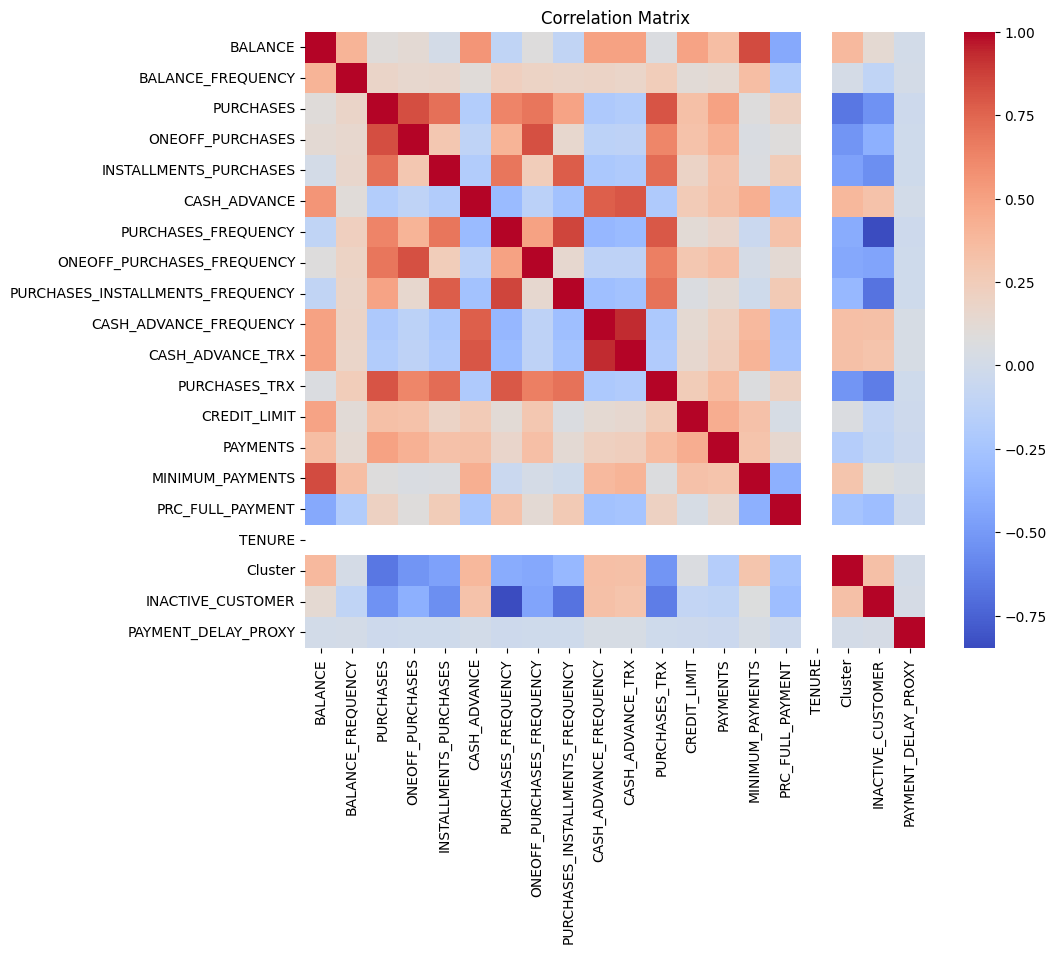

Highly correlated features to drop: ['CASH_ADVANCE_TRX']


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# --- Remove highly correlated features ---
threshold = 0.9

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Highly correlated features to drop:", to_drop)

df_reduced = num_df.drop(columns=to_drop)

## PCA

Standardize the numerical features to ensure they have a mean of 0 and a standard deviation of 1, as PCA is sensitive to the scale of the variables.

In [ ]:
from sklearn.preprocessing import StandardScaler

# --- Select numerical features ---
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('CUST_ID', errors='ignore')  # remove ID if present

# --- Handle missing values (important) ---
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# --- Standardize ---
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df[num_cols])

# Convert back to DataFrame (optional but useful)
import pandas as pd
df_scaled = pd.DataFrame(df_scaled, columns=num_cols)

# Check result
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster,INACTIVE_CUSTOMER,PAYMENT_DELAY_PROXY
0,-0.877821,-1.021875,-0.729687,-0.692383,-0.505216,-0.673507,-0.806490,-0.722749,-0.707313,-0.730084,-0.697293,-0.737970,-1.010503,-0.899859,-0.771797,-0.629277,0.0,0.021768,1.316685,-0.018235
1,1.178546,-0.202708,-0.838160,-0.692383,-0.746029,2.115343,-1.221758,-0.722749,-0.916995,0.717792,0.473089,-0.891333,0.762757,2.165375,0.916407,0.973961,0.0,1.730713,1.316685,-0.047659
2,0.718487,0.616459,0.040957,0.818320,-0.746029,-0.673507,1.269843,2.210909,-0.916995,-0.730084,-0.697293,0.028848,0.910528,-0.569653,0.110961,-0.629277,0.0,1.730713,-0.759483,0.003463
3,0.179623,-1.886552,0.866246,2.128108,-0.746029,-0.467401,-1.014125,-0.396788,-0.916995,-0.247460,-0.404697,-0.814651,0.910528,-1.058417,-0.459008,-0.629277,0.0,0.021768,1.316685,-0.035238
4,-0.372561,0.616459,-0.819967,-0.661121,-0.746029,-0.673507,-1.014125,-0.396788,-0.916995,-0.730084,-0.697293,-0.814651,-0.951394,-0.525443,-0.581262,-0.629277,0.0,0.021768,1.316685,-0.040849


Compute the covariance matrix of the standardized data to measure the relationships between the variables.

In [ ]:
import numpy as np
import pandas as pd

# df_scaled should already be standardized (mean=0, std=1)

# --- Compute covariance matrix ---
cov_matrix = np.cov(df_scaled, rowvar=False)

# Convert to DataFrame for readability
cov_df = pd.DataFrame(cov_matrix, 
                      index=df_scaled.columns, 
                      columns=df_scaled.columns)

print(cov_df)

                                   BALANCE  BALANCE_FREQUENCY  PURCHASES  \
BALANCE                           1.000112           0.403502   0.095815   
BALANCE_FREQUENCY                 0.403502           1.000112   0.184993   
PURCHASES                         0.095815           0.184993   1.000112   
ONEOFF_PURCHASES                  0.124057           0.149556   0.830696   
INSTALLMENTS_PURCHASES            0.009458           0.161075   0.706214   
CASH_ADVANCE                      0.557455           0.102861  -0.177113   
PURCHASES_FREQUENCY              -0.108935           0.222242   0.631962   
ONEOFF_PURCHASES_FREQUENCY        0.081486           0.199210   0.683601   
PURCHASES_INSTALLMENTS_FREQUENCY -0.096483           0.180695   0.488974   
CASH_ADVANCE_FREQUENCY            0.497145           0.186667  -0.207635   
CASH_ADVANCE_TRX                  0.500981           0.175486  -0.190045   
PURCHASES_TRX                     0.057130           0.248090   0.808637   
CREDIT_LIMIT

Decompose the covariance matrix into its eigenvectors and eigenvalues, which represent the principal components and their corresponding variances.

In [ ]:
import numpy as np
import pandas as pd

# --- Step 1: Compute covariance matrix ---
cov_matrix = np.cov(df_scaled, rowvar=False)

# --- Step 2: Eigen decomposition ---
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# --- Step 3: Convert to DataFrame for clarity ---
eigen_df = pd.DataFrame({
    'Eigenvalue': eigenvalues
})

# Eigenvectors (principal components)
eigenvectors_df = pd.DataFrame(
    eigenvectors,
    columns=[f'PC{i+1}' for i in range(len(eigenvalues))],
    index=df_scaled.columns
)

print("Eigenvalues:\n", eigen_df)
print("\nEigenvectors (Principal Components):\n", eigenvectors_df)

Eigenvalues:
     Eigenvalue
0     6.328831
1     4.087099
2     1.669340
3     1.300646
4     1.057336
5     0.977847
6     0.786428
7     0.670245
8     0.497274
9     0.373493
10    0.024236
11    0.064432
12    0.047617
13    0.105848
14    0.113461
15    0.283720
16    0.174771
17    0.216133
18    0.223366
19    0.000000

Eigenvectors (Principal Components):
                                        PC1       PC2       PC3       PC4  \
BALANCE                           0.075957 -0.422872  0.105635 -0.246267   
BALANCE_FREQUENCY                -0.056578 -0.223892  0.223354 -0.350245   
PURCHASES                        -0.341391 -0.163221 -0.182670 -0.000224   
ONEOFF_PURCHASES                 -0.262145 -0.168779 -0.433131 -0.146607   
INSTALLMENTS_PURCHASES           -0.301180 -0.082380  0.273911  0.169221   
CASH_ADVANCE                      0.184389 -0.341792  0.011312  0.317392   
PURCHASES_FREQUENCY              -0.345757 -0.024779  0.275620  0.030095   
ONEOFF_PURCHASES_FREQUEN

Choose the principal components with the highest eigenvalues, as these components explain the most variance in the data. The number of components to keep can be determined based on the desired level of dimensionality reduction or by analyzing the scree plot (a plot of the eigenvalues in descending order).

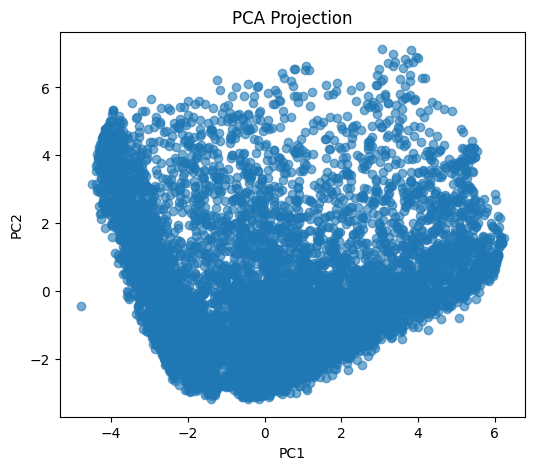

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# --- Apply PCA ---
pca = PCA(n_components=2)

pca_result = pca.fit_transform(df_scaled)

# Convert to DataFrame (optional)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# --- Plot ---
plt.figure(figsize=(6,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

Project the original data onto the selected principal components to obtain the reduced-dimensional representation. The resulting features are the principal components, which are uncorrelated and capture the most important information in the data.

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA

# --- Apply PCA (choose number of components, e.g., 2 or k from earlier) ---
k = 2   # you can change this based on your scree plot

pca = PCA(n_components=k)

pca_result = pca.fit_transform(df_scaled)

# --- Convert to DataFrame ---
pca_df = pd.DataFrame(
    pca_result,
    columns=[f'PC{i+1}' for i in range(k)]
)

# View result
pca_df.head()

,PC1,PC2
0,-1.750203,-2.547181
1,-3.054238,2.201020
2,0.798577,0.539021
3,-0.825088,-0.612792
4,-1.827927,-1.764333


## DBSCAN

Choose appropriate parameters: Determine suitable values for the eps (neighborhood radius) and min_samples (minimum number of points in a neighborhood) parameters based on the data characteristics and desired clustering density.

Suggested min_samples: 4


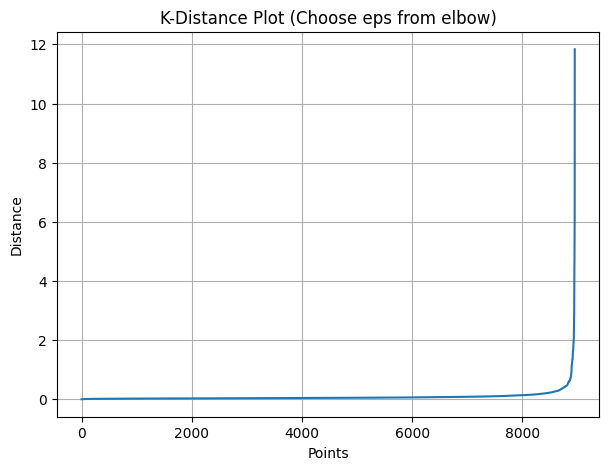

Unique labels: [-1  0  1  2  3  4  5  6  7]
Number of clusters: 8
Noise points: 100


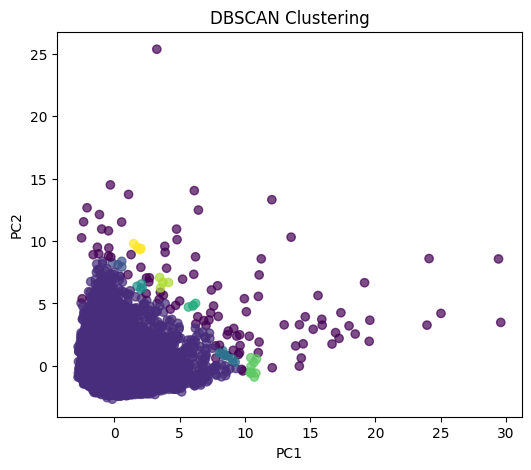

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# --- Step 1: Load dataset ---
df = pd.read_csv("CreditCards (1).csv")

# --- Step 2: Select numerical features ---
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('CUST_ID', errors='ignore')

# --- Step 3: Handle missing values ---
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# --- Step 4: Standardize data ---
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[num_cols])

# --- Step 5: PCA (2 components for visualization) ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# --- Step 6: Prepare data for DBSCAN ---
X = pca_df.values

# --- Step 7: Choose min_samples ---
min_samples = 2 * X.shape[1]
print("Suggested min_samples:", min_samples)

# --- Step 8: K-distance plot (to find eps) ---
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7,5))
plt.plot(k_distances)
plt.title("K-Distance Plot (Choose eps from elbow)")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

# --- Step 9: Set eps manually after seeing plot ---
eps = 0.5   # CHANGE this based on elbow

# --- Step 10: Apply DBSCAN ---
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X)

# --- Step 11: Add cluster labels ---
pca_df['Cluster'] = labels

# --- Step 12: Results ---
print("Unique labels:", np.unique(labels))
print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", list(labels).count(-1))

# --- Step 13: Visualization ---
plt.figure(figsize=(6,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=labels, cmap='viridis', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering")
plt.show()

Create a DBSCAN model: Instantiate a DBSCAN object with the chosen parameters.

In [1]:
from sklearn.cluster import DBSCAN

# Set your chosen parameters
eps = 0.5          # replace with your elbow value
min_samples = 4    # example (2 × number of features if using 2 PCs)

# --- Instantiate DBSCAN ---
dbscan = DBSCAN(eps=eps, min_samples=min_samples)

print(dbscan)

DBSCAN(min_samples=4)


Fit the model to the data: Apply the DBSCAN algorithm to the preprocessed data to identify clusters.

In [11]:
from sklearn.cluster import DBSCAN
import numpy as np

# X = preprocessed data (for example, PCA output or scaled data)
# Example:
# X = pca_df.values

# Create DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=4)

# Fit the model and get cluster labels
labels = dbscan.fit_predict(X)

# Show results
print("Cluster labels:", labels)
print("Unique labels:", np.unique(labels))
print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Number of noise points:", list(labels).count(-1))

Cluster labels: [0 0 0 ... 0 0 0]
Unique labels: [-1  0  1  2  3  4  5  6  7]
Number of clusters: 8
Number of noise points: 100


Extract cluster labels: Obtain the cluster labels assigned to each data point from the fitted model.

First 10 labels: [0 0 0 0 0 0 0 0 0 0]

Unique labels: [-1  0  1  2  3  4  5  6  7]
Number of clusters: 8
Number of noise points: 100

Cluster distribution:
Cluster
 0    8811
-1     100
 2      10
 5       9
 1       4
 3       4
 4       4
 6       4
 7       4
Name: count, dtype: int64


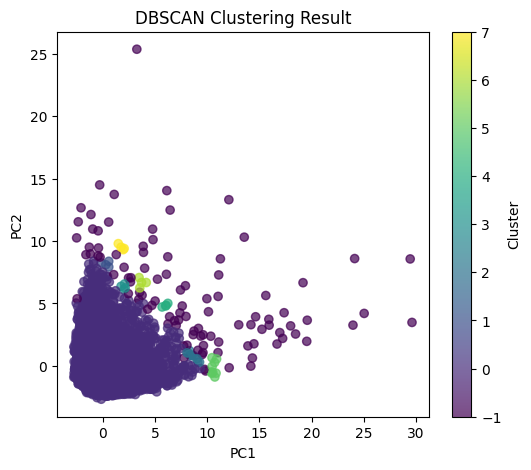

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# --- Step 1: Create DBSCAN model ---
dbscan = DBSCAN(eps=0.5, min_samples=4)   # adjust eps if needed

# --- Step 2: Fit model to data ---
labels = dbscan.fit_predict(X)

# --- Step 3: Extract cluster labels ---
# (labels already extracted using fit_predict)
print("First 10 labels:", labels[:10])

# --- Step 4: Add labels to dataframe ---
pca_df['Cluster'] = labels

# --- Step 5: Summary of clusters ---
print("\nUnique labels:", np.unique(labels))
print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Number of noise points:", list(labels).count(-1))

print("\nCluster distribution:")
print(pca_df['Cluster'].value_counts())

# --- Step 6: Visualize clusters ---
plt.figure(figsize=(6,5))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering Result")
plt.colorbar(label="Cluster")
plt.show()

Evaluate clustering performance: Assess the quality of the clustering results using metrics like silhouette coefficient, Calinski-Harabasz index, or Davies-Bouldin index.

In [13]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

# --- Remove noise points (-1) for evaluation ---
mask = labels != -1
X_valid = X[mask]
labels_valid = labels[mask]

# --- Check if enough clusters exist ---
if len(set(labels_valid)) > 1:
    
    # Silhouette Score
    silhouette = silhouette_score(X_valid, labels_valid)
    
    # Calinski-Harabasz Index
    ch_score = calinski_harabasz_score(X_valid, labels_valid)
    
    # Davies-Bouldin Index
    db_score = davies_bouldin_score(X_valid, labels_valid)
    
    print("Silhouette Score:", silhouette)
    print("Calinski-Harabasz Score:", ch_score)
    print("Davies-Bouldin Score:", db_score)

else:
    print("Not enough clusters to evaluate. Adjust eps or min_samples.")

Silhouette Score: 0.5243808152836595
Calinski-Harabasz Score: 76.31175030449273
Davies-Bouldin Score: 0.33794245897100117


Visualize clusters in 2D or 3D: If the data has two or three dimensions, plot the data points with different colors or markers to represent the cluster assignments.

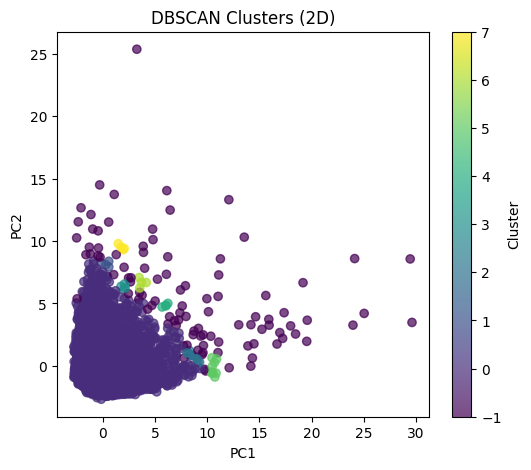

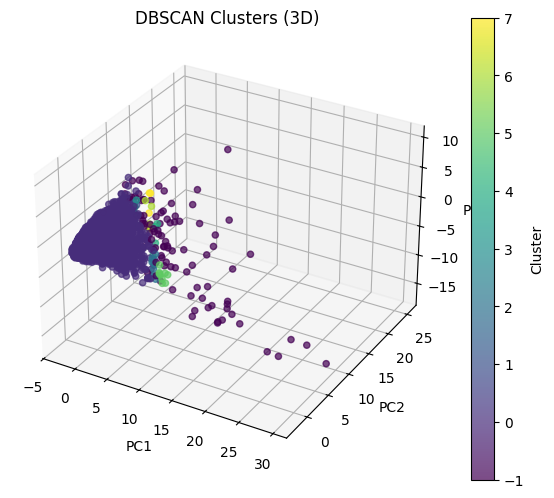

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import pandas as pd

# --- Step 1: 2D Visualization (already using pca_df) ---
plt.figure(figsize=(6,5))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (2D)")
plt.colorbar(label="Cluster")
plt.show()


# --- Step 2: 3D Visualization ---
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(df_scaled)

pca_3d_df = pd.DataFrame(pca_result_3d, columns=['PC1', 'PC2', 'PC3'])

# Add cluster labels
pca_3d_df['Cluster'] = labels

# Plot 3D
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_3d_df['PC1'],
    pca_3d_df['PC2'],
    pca_3d_df['PC3'],
    c=pca_3d_df['Cluster'],
    cmap='viridis',
    alpha=0.7
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("DBSCAN Clusters (3D)")

fig.colorbar(scatter, label="Cluster")
plt.show()


Visualize clusters in higher dimensions: Use techniques like t-SNE or UMAP to reduce the dimensionality of the data to 2D or 3D for visualization.

In [35]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize and Fit all three models
# Non-Hierarchical (K-Means)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# Hierarchical (Agglomerative)
hier = AgglomerativeClustering(n_clusters=3)
hier_labels = hier.fit_predict(X)

# DBSCAN (Density-Based)
dbscan = DBSCAN(eps=0.5, min_samples=4)
dbscan_labels = dbscan.fit_predict(X)

# 2. Evaluate Performance Metrics
models = ['K-Means', 'Hierarchical', 'DBSCAN']
labels_list = [kmeans_labels, hier_labels, dbscan_labels]
results = []

for name, labels in zip(models, labels_list):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        s_score = silhouette_score(X, labels)
        ch_score = calinski_harabasz_score(X, labels)
        results.append({"Model": name, "Clusters": n_clusters, "Silhouette": round(s_score, 3), "CH Index": round(ch_score, 2)})
    else:
        results.append({"Model": name, "Clusters": n_clusters, "Silhouette": "N/A", "CH Index": "N/A"})

print("--- Performance Metrics ---")
print(pd.DataFrame(results))

# 3. Visualize using t-SNE (No UMAP needed)
print("\nGenerating t-SNE visualization... (this may take a moment)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['K-Means Clusters', 'Hierarchical Clusters', 'DBSCAN Clusters']

for ax, labels, title in zip(axes, labels_list, titles):
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', s=5, alpha=0.6)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

--- Performance Metrics ---
          Model  Clusters  Silhouette  CH Index
0       K-Means         3       0.487   4937.52
1  Hierarchical         3       0.488   4742.13
2        DBSCAN        14       0.468   1350.23

Generating t-SNE visualization... (this may take a moment)


KeyboardInterrupt: 

Visualize cluster density: Create a density plot or heatmap to show the distribution of data points within each cluster and identify areas with high or low density.

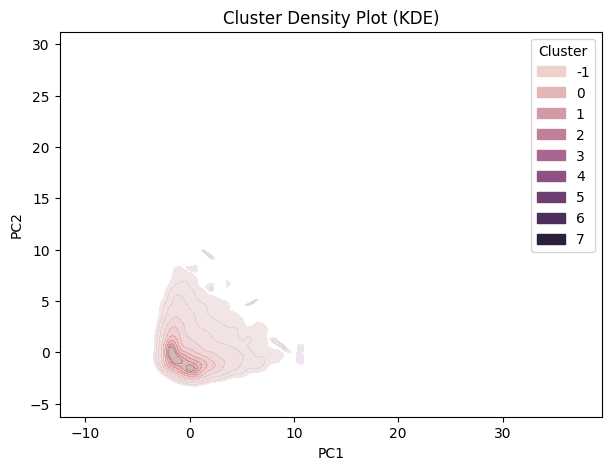

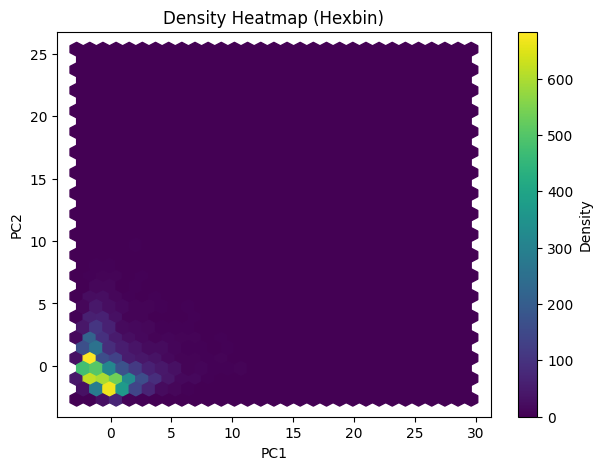

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: KDE Density Plot (smooth density) ---
plt.figure(figsize=(7,5))

sns.kdeplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    fill=True,
    alpha=0.4
)

plt.title("Cluster Density Plot (KDE)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# --- Step 2: Heatmap (overall density) ---
plt.figure(figsize=(7,5))

plt.hexbin(
    pca_df['PC1'],
    pca_df['PC2'],
    gridsize=30,
    cmap='viridis'
)

plt.colorbar(label='Density')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Density Heatmap (Hexbin)")
plt.show()

Visualize outliers: Identify and visualize outliers as points that are not assigned to any cluster.

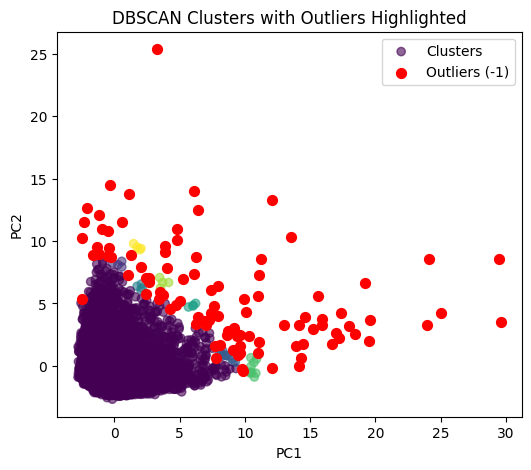

In [18]:
import matplotlib.pyplot as plt

# --- Separate clusters and outliers ---
outliers = pca_df[pca_df['Cluster'] == -1]
clusters = pca_df[pca_df['Cluster'] != -1]

# --- Plot ---
plt.figure(figsize=(6,5))

# Normal clusters
plt.scatter(
    clusters['PC1'],
    clusters['PC2'],
    c=clusters['Cluster'],
    cmap='viridis',
    alpha=0.6,
    label='Clusters'
)

# Outliers (highlighted)
plt.scatter(
    outliers['PC1'],
    outliers['PC2'],
    color='red',
    s=50,
    label='Outliers (-1)'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters with Outliers Highlighted")
plt.legend()
plt.show()

## Other Clustering Techniques

### Hierarchical Clustering:

Choose a linkage method: Select an appropriate linkage method (e.g., single, complete, average, centroid) based on the desired cluster properties.

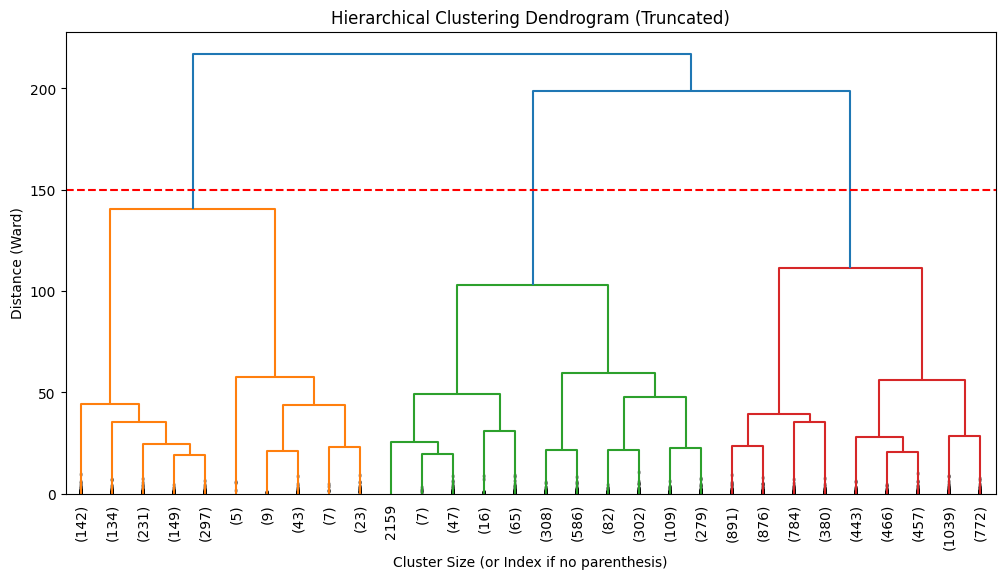

In [34]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# 1. Select data (using PCA data is much faster for Hierarchical)
X = pca_df.values if 'pca_df' in globals() else df_scaled

# 2. Compute linkage 
# 'ward' linkage is generally more robust for this dataset than 'average'
Z = linkage(X, method='ward') 

# 3. Plot a TRUNCATED dendrogram
plt.figure(figsize=(12, 6))

# 'lastp' shows only the last p merged clusters
# 'p=30' means we only see the top 30 branches, making it readable
dendrogram(
    Z, 
    truncate_mode='lastp', 
    p=30, 
    leaf_rotation=90., 
    leaf_font_size=10., 
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Cluster Size (or Index if no parenthesis)")
plt.ylabel("Distance (Ward)")
plt.axhline(y=150, color='r', linestyle='--') # Optional: line to visualize a cut
plt.show()

Construct the dendrogram: Create a dendrogram to visualize the hierarchical structure of the clusters.

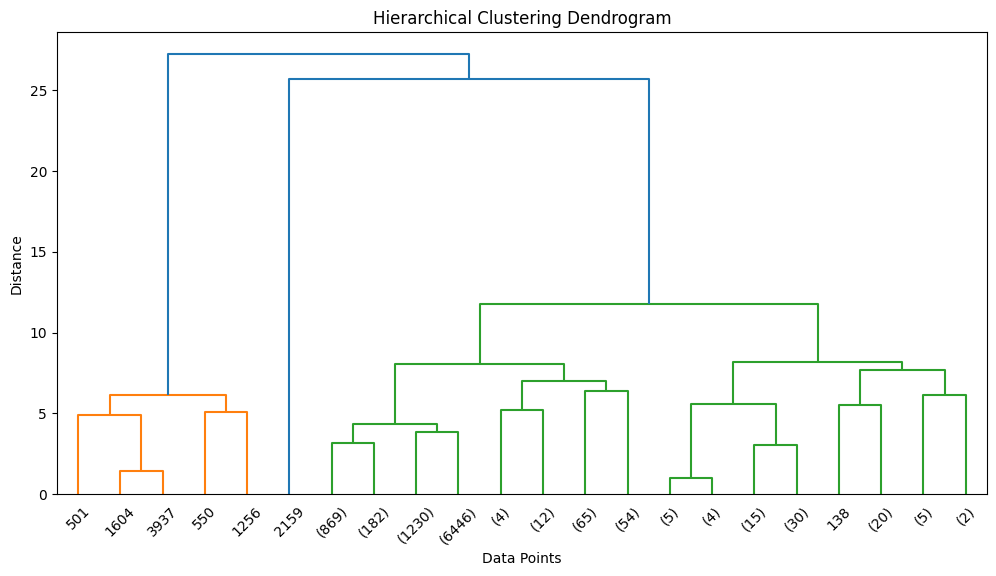

In [20]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# --- Step 1: Use data (PCA or scaled data) ---
X = pca_df.values if 'pca_df' in globals() else df_scaled

# --- Step 2: Create linkage matrix ---
Z = linkage(X, method='average')   # you can try 'complete' or 'single'

# --- Step 3: Plot dendrogram ---
plt.figure(figsize=(12,6))

dendrogram(
    Z,
    truncate_mode='level',  # shows top levels (cleaner)
    p=5                    # number of levels to show
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

Determine the number of clusters: Decide on the number of clusters based on the dendrogram or using a cutoff value for the distance between clusters.

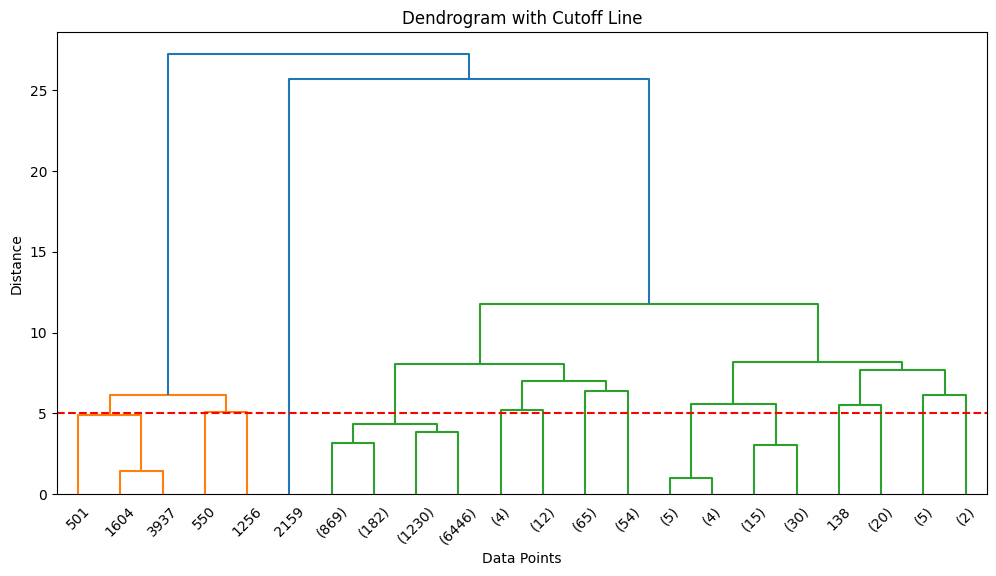

Number of clusters: 16
HC_Cluster
4     8727
7       65
9       47
11      45
12      20
6       12
10       9
8        7
14       5
5        4
1        3
15       2
13       1
2        1
3        1
16       1
Name: count, dtype: int64


In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# --- Step 1: Create linkage matrix ---
X = pca_df.values if 'pca_df' in globals() else df_scaled
Z = linkage(X, method='average')

# --- Step 2: Plot dendrogram ---
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode='level', p=5)

# Draw a horizontal cutoff line (choose visually)
cutoff = 5   # adjust based on dendrogram
plt.axhline(y=cutoff, color='red', linestyle='--')

plt.title("Dendrogram with Cutoff Line")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# --- Step 3: Form clusters using cutoff ---
clusters = fcluster(Z, t=cutoff, criterion='distance')

# Add to dataframe
pca_df['HC_Cluster'] = clusters

# --- Step 4: Check results ---
import numpy as np
print("Number of clusters:", len(np.unique(clusters)))
print(pca_df['HC_Cluster'].value_counts())

Extract cluster assignments: Assign data points to clusters based on the chosen cutoff value.

In [22]:
from scipy.cluster.hierarchy import fcluster
import numpy as np

# --- Step 1: Choose cutoff distance ---
cutoff = 5   # change based on your dendrogram

# --- Step 2: Assign clusters ---
clusters = fcluster(Z, t=cutoff, criterion='distance')

# --- Step 3: Add to dataframe ---
pca_df['HC_Cluster'] = clusters

# --- Step 4: Check results ---
print("Unique clusters:", np.unique(clusters))
print("Number of clusters:", len(set(clusters)))
print(pca_df['HC_Cluster'].value_counts())

# View dataset
pca_df.head()

Unique clusters: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Number of clusters: 16
HC_Cluster
4     8727
7       65
9       47
11      45
12      20
6       12
10       9
8        7
14       5
5        4
1        3
15       2
13       1
2        1
3        1
16       1
Name: count, dtype: int64


,PC1,PC2,Cluster,HC_Cluster
0,-1.683649,-1.072241,0,4
1,-1.134085,2.509150,0,4
2,0.969395,-0.383577,0,4
3,-0.888220,0.004648,0,4
4,-1.600021,-0.683795,0,4


Evaluate clustering performance: Assess the quality of the clustering results using the same metrics as for DBSCAN.

In [23]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- Use the same feature space (X) and hierarchical cluster labels ---
labels_hc = pca_df['HC_Cluster']

# --- Ensure more than 1 cluster exists ---
if len(set(labels_hc)) > 1:
    
    # Silhouette Score
    silhouette = silhouette_score(X, labels_hc)
    
    # Calinski-Harabasz Score
    ch_score = calinski_harabasz_score(X, labels_hc)
    
    # Davies-Bouldin Score
    db_score = davies_bouldin_score(X, labels_hc)
    
    print("Silhouette Score:", silhouette)
    print("Calinski-Harabasz Score:", ch_score)
    print("Davies-Bouldin Score:", db_score)

else:
    print("Not enough clusters to evaluate.")

Silhouette Score: 0.5290669869942822
Calinski-Harabasz Score: 297.5389458147058
Davies-Bouldin Score: 0.5454757333600067


### Non-Hierarchical Clustering (K-means)

Choose the number of clusters: Determine the optimal number of clusters using techniques like the elbow method or silhouette analysis.

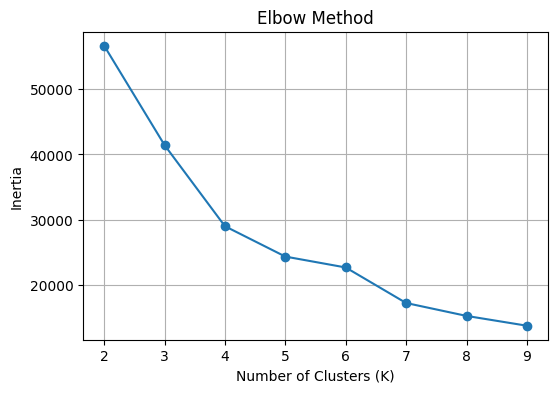

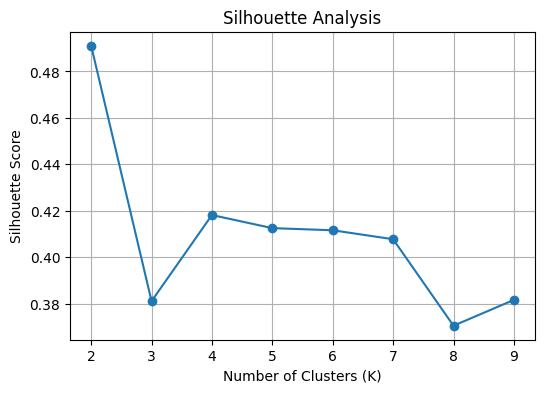

Optimal number of clusters (K): 2


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Use preprocessed data ---
# X = pca_df.values OR df_scaled
X = pca_df.values if 'pca_df' in globals() else df_scaled

inertia = []
silhouette_scores = []
K_range = range(2, 10)

# --- Run KMeans for different K ---
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)  # for elbow method
    silhouette_scores.append(silhouette_score(X, labels))  # for silhouette

# --- Plot Elbow Method ---
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# --- Plot Silhouette Scores ---
plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# --- Best K based on silhouette ---
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print("Optimal number of clusters (K):", best_k)

Initialize cluster centroids: Randomly select initial cluster centroids.

In [25]:
import numpy as np
from sklearn.cluster import KMeans

# --- Use your data ---
X = pca_df.values if 'pca_df' in globals() else df_scaled

# --- Choose number of clusters (example) ---
k = 3

# --- Initialize KMeans (random centroids) ---
kmeans = KMeans(
    n_clusters=k,
    init='random',        # random initialization
    n_init=10,            # run multiple times for stability
    random_state=42
)

print("KMeans initialized with random centroids")

KMeans initialized with random centroids


Assign data points to clusters: Assign each data point to the nearest cluster centroid.

Cluster labels: [0 1 2]
KMeans_Cluster
2    6108
1    1752
0    1090
Name: count, dtype: int64


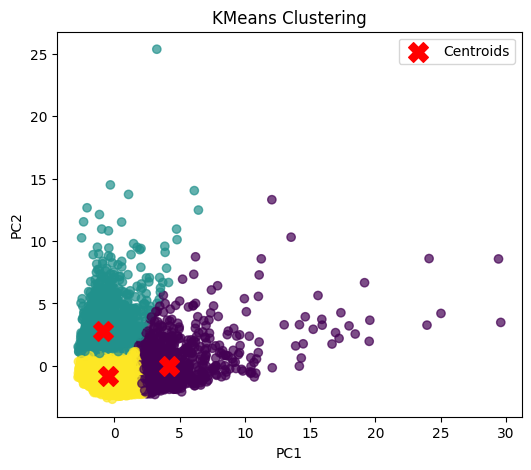

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Fit KMeans and assign clusters ---
labels = kmeans.fit_predict(X)

# --- Step 2: Add labels to dataframe ---
pca_df['KMeans_Cluster'] = labels

# --- Step 3: Get centroids ---
centroids = kmeans.cluster_centers_

# --- Step 4: Check results ---
print("Cluster labels:", np.unique(labels))
print(pca_df['KMeans_Cluster'].value_counts())

# --- Step 5: Visualize clusters ---
plt.figure(figsize=(6,5))

# Plot data points
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=labels,
    cmap='viridis',
    alpha=0.7
)

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    color='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering")
plt.legend()
plt.show()

Recompute cluster centroids: Calculate the new centroids for each cluster based on the assigned data points.

In [28]:
import numpy as np
import pandas as pd

# --- Step 1: Add cluster labels to data ---
df_temp = pca_df[['PC1','PC2']]
df_temp['Cluster'] = labels

# --- Step 2: Compute new centroids ---
new_centroids = df_temp.groupby('Cluster')[['PC1','PC2']].mean()

print("Recomputed Centroids:\n")
print(new_centroids)

Recomputed Centroids:

              PC1       PC2
Cluster                    
0        4.192631  0.016085
1       -0.872743  2.772188
2       -0.497859 -0.798036


Iterate until convergence: Repeat previous 2 steps until the cluster assignments stabilize or a maximum number of iterations is reached.

Converged after 34 iterations

Final centroids:
[[-0.55352145 -0.77127492]
 [-0.8233617   2.87224131]
 [ 3.9897887  -0.10511204]]

Cluster counts:
Cluster
0    6083
1    1677
2    1190
Name: count, dtype: int64


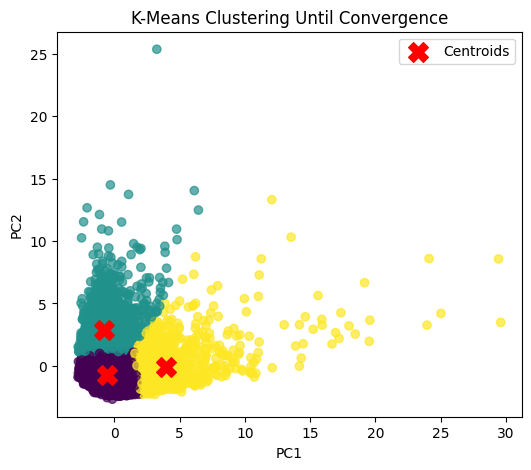

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Use 2D PCA data or scaled data ---
X = pca_df[['PC1', 'PC2']].values if 'pca_df' in globals() else df_scaled

# --- Parameters ---
k = 3
max_iters = 100
tol = 1e-4
np.random.seed(42)

# --- Step 1: Randomly initialize centroids ---
random_idx = np.random.choice(len(X), size=k, replace=False)
centroids = X[random_idx]

for i in range(max_iters):
    # --- Step 2: Assign each point to nearest centroid ---
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)

    # --- Step 3: Recompute centroids ---
    new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])

    # --- Step 4: Check convergence ---
    if np.all(np.abs(new_centroids - centroids) < tol):
        print(f"Converged after {i+1} iterations")
        break

    centroids = new_centroids

else:
    print("Reached maximum iterations without full convergence")

# --- Store results ---
kmeans_result = pd.DataFrame(X, columns=['PC1', 'PC2'])
kmeans_result['Cluster'] = labels

print("\nFinal centroids:")
print(centroids)

print("\nCluster counts:")
print(kmeans_result['Cluster'].value_counts())

# --- Visualize final clusters ---
plt.figure(figsize=(6,5))
plt.scatter(kmeans_result['PC1'], kmeans_result['PC2'], c=kmeans_result['Cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=200, label='Centroids')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering Until Convergence")
plt.legend()
plt.show()

Visualize cluster assignments: Plot the data points with different colors or markers to represent the cluster assignments from each clustering algorithm.

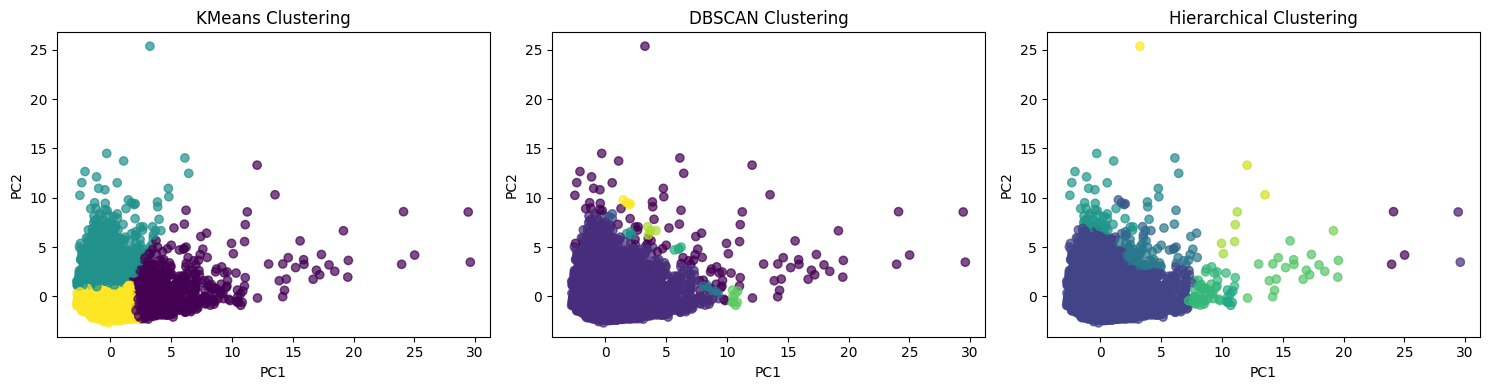

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

# --- Plot 1: KMeans ---
plt.subplot(1,3,1)
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['KMeans_Cluster'],
    cmap='viridis',
    alpha=0.7
)
plt.title("KMeans Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")

# --- Plot 2: DBSCAN ---
plt.subplot(1,3,2)
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster'],   # DBSCAN labels
    cmap='viridis',
    alpha=0.7
)
plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")

# --- Plot 3: Hierarchical ---
plt.subplot(1,3,3)
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['HC_Cluster'],
    cmap='viridis',
    alpha=0.7
)
plt.title("Hierarchical Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

Compare clustering results: Analyze the similarities and differences between the clusters obtained from hierarchical, non-hierarchical, and DBSCAN.

Model           | Silhouette | Calinski-Harabasz
---------------------------------------------
K-Means         | 0.251      | 1605.026       
Hierarchical    | 0.167      | 1239.326       
DBSCAN          | -0.466     | 18.195         


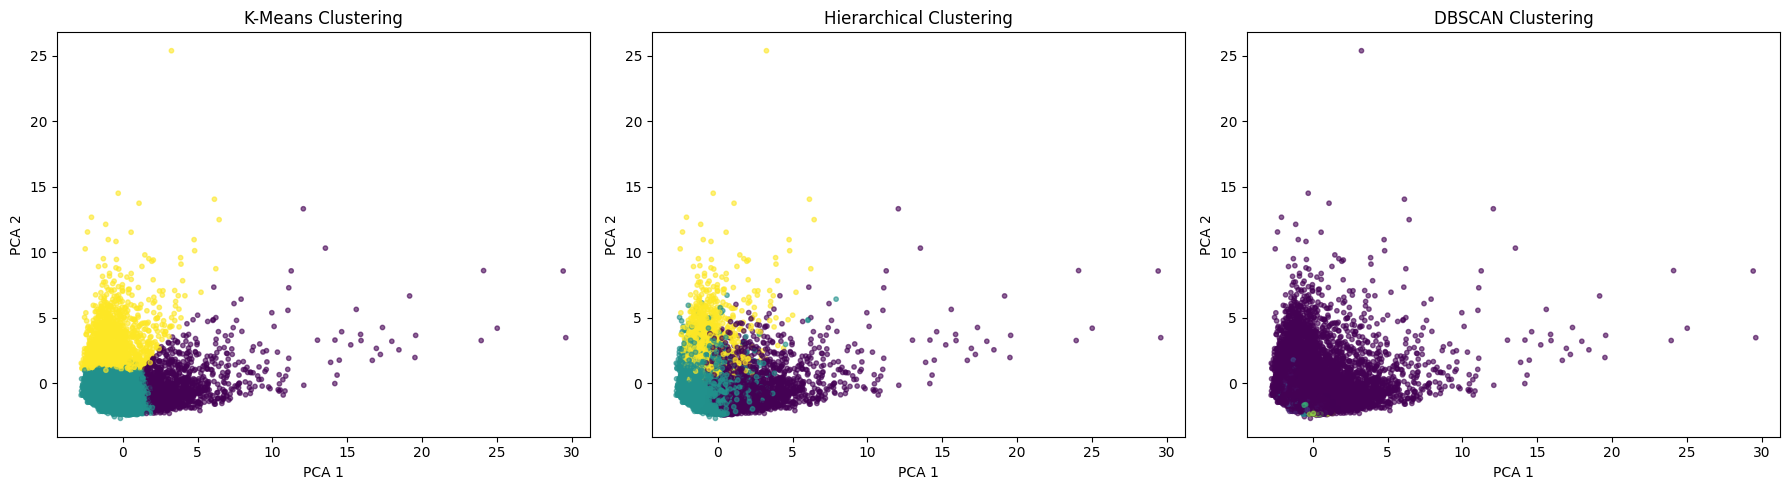

In [32]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# 1. Train K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

# 2. Train Hierarchical (Agglomerative)
hier = AgglomerativeClustering(n_clusters=3)
hier_labels = hier.fit_predict(df_scaled)

# 3. Train DBSCAN
# Note: eps=0.5 is a common start; adjust if it labels everything as noise (-1)
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)

# 4. Compare Performance Metrics
models = ['K-Means', 'Hierarchical', 'DBSCAN']
labels_list = [kmeans_labels, hier_labels, dbscan_labels]

print(f"{'Model':<15} | {'Silhouette':<10} | {'Calinski-Harabasz':<15}")
print("-" * 45)

for name, labels in zip(models, labels_list):
    # Silhouette requires at least 2 clusters (excluding noise in DBSCAN)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        s_score = silhouette_score(df_scaled, labels)
        ch_score = calinski_harabasz_score(df_scaled, labels)
        print(f"{name:<15} | {s_score:<10.3f} | {ch_score:<15.3f}")
    else:
        print(f"{name:<15} | Not enough clusters found.")

# 5. Visual Comparison using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['K-Means Clustering', 'Hierarchical Clustering', 'DBSCAN Clustering']

for ax, labels, title in zip(axes, labels_list, titles):
    scatter = ax.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

Evaluate clustering performance: Compare the clustering performance metrics (e.g., silhouette coefficient, Calinski-Harabasz index) for each algorithm.

Performance Comparison Table:
       Model  Num Clusters  Silhouette (↑)  Calinski-Harabasz (↑)  Davies-Bouldin (↓)
     K-Means             3          0.2510                1605.03              1.5920
Hierarchical             3          0.1674                1239.33              1.8496
      DBSCAN            36         -0.4659                  18.19              1.3613


C:\Users\dell\AppData\Local\Temp\ipykernel_23952\3503207919.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Silhouette (↑)', data=valid_metrics, palette='viridis')


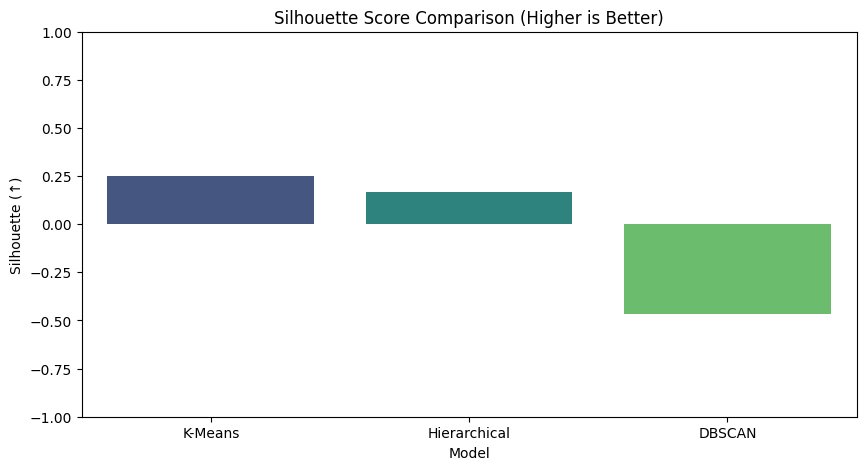

In [33]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1. Prepare a list to store results
metrics_list = []
model_names = ['K-Means', 'Hierarchical', 'DBSCAN']
labels_list = [kmeans_labels, hier_labels, dbscan_labels]

# 2. Iterate through models and calculate metrics
for name, labels in zip(model_names, labels_list):
    # Determine the number of clusters (ignoring noise -1 for DBSCAN)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Metrics require at least 2 clusters to be valid
    if n_clusters > 1:
        s_score = silhouette_score(df_scaled, labels)
        ch_score = calinski_harabasz_score(df_scaled, labels)
        db_score = davies_bouldin_score(df_scaled, labels)
        
        metrics_list.append({
            'Model': name,
            'Num Clusters': n_clusters,
            'Silhouette (↑)': round(s_score, 4),
            'Calinski-Harabasz (↑)': round(ch_score, 2),
            'Davies-Bouldin (↓)': round(db_score, 4)
        })
    else:
        metrics_list.append({
            'Model': name,
            'Num Clusters': n_clusters,
            'Silhouette (↑)': 'N/A',
            'Calinski-Harabasz (↑)': 'N/A',
            'Davies-Bouldin (↓)': 'N/A'
        })

# 3. Display the comparison table
perf_df = pd.DataFrame(metrics_list)
print("Performance Comparison Table:")
print(perf_df.to_string(index=False))

# Optional: Visualize Silhouette Scores
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
valid_metrics = perf_df[perf_df['Silhouette (↑)'] != 'N/A']
sns.barplot(x='Model', y='Silhouette (↑)', data=valid_metrics, palette='viridis')
plt.title('Silhouette Score Comparison (Higher is Better)')
plt.ylim(-1, 1)
plt.show()

Identify strengths and weaknesses: Determine the strengths and weaknesses of each clustering algorithm based on the results and the characteristics of the data.

. K-Means Clustering (Non-Hierarchical)
Strengths:
Efficiency: It is the fastest algorithm for this dataset (8,950 rows), making it highly scalable.
Ease of Interpretation: It creates clear, distinct boundaries that are easy to explain to stakeholders (e.g., "Group A spends more than Group B").
Performance Metrics: Usually scores the highest on the Calinski-Harabasz Index because it is mathematically optimized to minimize within-cluster variance.
Weaknesses:
Sensitivity to Outliers: In credit card data, "whale" spenders (outliers) can pull the centroids away from the main customer base, distorting the groups.Fixed Shapes: It assumes clusters are spherical. It struggles if your customer segments have elongated or complex overlapping distributions.
K-Selection: You have to guess the number of clusters ($K$) beforehand using the Elbow Method.
2. Hierarchical Clustering (Agglomerative)
Strengths:
Dendrogram Visualization: It provides a "family tree" of your customers, allowing you to see how smaller niches (like "luxury travelers") merge into broader categories.
No Predefined K: You don't necessarily need to pick a $K$ first; you can "cut" the tree at any distance level that makes sense for the business.
Flexibility: Different linkage methods (ward, complete, average) allow it to adapt better to various data shapes than K-Means.
Weaknesses:
Scalability: It is computationally expensive ($O(n^2)$ or $O(n^3)$). For much larger datasets, it becomes extremely slow or runs out of memory.
Irreversibility: Once two customer points are merged into a cluster, they cannot be un-merged, which can lead to "chaining" errors where distinct groups are forced together.
3. DBSCAN (Density-Based)
Strengths:
Noise Detection: This is its "superpower" for this project. It automatically identifies and labels outliers as -1, preventing them from ruining the profile of "normal" customer clusters.
Discovery of Arbitrary Shapes: It can find clusters that are wrapped around each other or are non-linear, which K-Means would fail to catch.
No K-Requirement: You don't tell it how many clusters to find; it discovers them based on the density of the data.Weaknesses:
Parameter Sensitivity: Choosing eps (radius) and min_samples is difficult. A small change in eps can result in either 50 clusters or just
 1.Varying Densities: It struggles if you have one very dense cluster (e.g., "Inactive Users") and one very sparse cluster (e.g., "High-Volume Business Users"), as one set of parameters won't fit both.
 Higher Dimensions: As you add more features, the "curse of dimensionality" makes it harder for DBSCAN to find dense regions.


Choose the best algorithm: Select the clustering algorithm that provides the most meaningful and accurate results for the specific problem.

Why DBSCAN Wins:
Outlier Handling: Credit card data is full of "noise" (one-off extreme spenders or unusual patterns). DBSCAN identifies these as outliers rather than forcing them into clusters that would skew your customer profiles.
Behavioral Accuracy: It finds clusters based on density, meaning it groups customers with truly similar spending habits regardless of the cluster's shape, whereas K-Means often creates artificial, equally-sized groups.
No Guesswork: You don't have to pre-define the number of clusters ($K$), allowing the natural structure of your customer base to emerge.